# GO Analysis for WGCNA
## Phase 2 

Gene ontology of modules from [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/wgcna_p2.ipynb). Following [Gurr code](https://github.com/SamGurr/Pgenerosa_OA_TagSeq/blob/main/TagSeq/Analysis/Scripts/GO_Analysis_WGCNA_all.R)

Since we don't have log fold change (because we aren't looking at differential expression), we can only do an over-representation analysis (ORA) - provide a gene list of interest (genes in a significantly correlated module) and a universal gene list (after filtering for wgcna - so *not* all genes in the CV genome, but rather what went in as input to wgcna)

## 0. load libraries

In [2]:
library(tidyverse)
library(goseq)
library(reshape2)
library(Rmisc)
library(ggpubr)
library(gridExtra)
library(forcats)
library(zoo)
library(ComplexHeatmap)
library(GO.db)
library(GSEABase)
library(clusterProfiler)

## 1. load data
WGCNA module membership, module colors, and goslim_generic.obo

#### A. gene annotation to GO.term - long format
matches GO terms to *C. virginica* genes - one GO term per row (so genes are duplicated among rows)

In [3]:
annot <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
colnames(annot)[1] <- 'Gene'
colnames(annot)[2] <- 'GO.terms'

# One row for each gene and GO.term
term2gene <- annot %>%
  separate_rows(GO.terms, sep = ";") %>% # one row for each GO.term
  filter(!is.na(GO.terms) & GO.terms != "") %>% # remove genes without GO terms
  dplyr::select(term = GO.terms, gene = Gene) # rename columns for GO 

# 

head(term2gene)

term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


this becomes input for `enricher` down below

get term names for GO IDs

In [4]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)    

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


#### B. GOslim data

GO Slim - higher level of GO used to summarize GO results into broader categories (the parent terms)

In [5]:
slim <- getOBOCollection("http://current.geneontology.org/ontology/subsets/goslim_generic.obo")
class(slim)

[1] "OBOCollection"
attr(,"package")
[1] "GSEABase"

In [6]:
# 1. Get the GO IDs
slim_ids <- ids(slim)

# 2. Get the IDs that belong to the generic subset
slim_ids <- ids(slim["goslim_generic" ])

# 3. Get the terms for those specific IDs
# use the GO.db package because it's much faster and more reliable for names
slim_terms <- Term(slim_ids)

# 4. Create lookup table 
slim_lookup <- data.frame(
  SlimID = names(slim_terms), # parent ID
  GOSlim_Bin = as.character(slim_terms), # biological term
  stringsAsFactors = FALSE
)

head(slim_lookup)

,SlimID,GOSlim_Bin
,<chr>,<chr>
1,GO:0000228,nuclear chromosome
2,GO:0000278,mitotic cell cycle
3,GO:0000910,cytokinesis
4,GO:0001618,virus receptor activity
5,GO:0002181,cytoplasmic translation
6,GO:0002376,immune system process


this table can be used to assign GO terms to broader categories - however, this table only contains parent terms (SlimID), so cannot directly be merged with GO results - need to match the parent terms to the GO IDs

In [7]:
# 1. Get a list of all ancestors for every GO term in WGCNA results
# This creates a mapping of Specific_ID -> All_Ancestors
all_ancestors <- as.list(GOBPANCESTOR)

# lookup vector - parent GO terms
target_slim_ids <- unique(slim_lookup$SlimID)

# 2. make lookup function
find_slim_parent <- function(specific_id, slim_ids) {
  if (is.na(specific_id)) return(NA_character_) # if GO term isn't in ancestor lookup
  if (specific_id %in% slim_ids) return(specific_id) # if GO term is the parent term
  
  # Get ancestors from the GO.db object
  ancestors <- all_ancestors[[specific_id]]
  
  if (is.null(ancestors)) return(NA_character_) # if no ancestor term
  
  # Find which ancestors are in your Slim list
  match <- intersect(ancestors, slim_ids)
  
  if (length(match) == 0) return(NA_character_)
  return(as.character(match[1])) 
}


#### C. Gene info
read in gene info from [wgcna_p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/wgcna/wgcna_p2.ipynb)

contains the gene name, matching GO terms, module color, gene significance (GS) for every treatment, and module membership (MM) for each module

In [8]:
geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_GeneInfo.csv') 
head(geneInfo) 

,Gene,GO.terms,ModuleColor,GS.Actual_shell_growth_mg,GS.Actual_tissue_growth_mg,GS.Ratio_tissue_shell_mg,GS.P1_trtmt_code,GS.P1_temp_code,GS.P1_DO_code,GS.P2_trtmt_code,⋯,MMmagenta,MMpink,MMcyan,MMred,MMbrown,MMgreen,MMsalmon,MMturquoise,MMmidnightblue,MMpurple
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,green,0.14571142,0.05937969,-0.109564792,-0.12499754,-0.01985215,-0.128608602,-0.05370241,⋯,0.009638715,0.14857330,0.150462603,0.0014763335,0.10330871,0.20884429,0.07217231,-0.058705838,-0.063588526,-0.168151337
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,black,0.02275339,-0.06710301,-0.113811162,0.01333703,0.03823132,-0.004338504,0.15336122,⋯,0.134078073,-0.12596425,-0.169428680,0.0001014633,-0.07418067,0.04122113,-0.07353120,-0.008073588,0.075545608,0.009819899
3,LOC111099040,GO:0005515;GO:0007169;GO:0035556,black,-0.02129411,-0.03599048,-0.009529534,0.19284124,0.10132621,0.163054335,0.15998130,⋯,0.209695014,0.07264407,-0.093507897,-0.1093702268,-0.03710835,0.24539274,0.12959445,-0.109145432,-0.007852902,-0.065906431
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,black,-0.04812120,-0.10076555,-0.011929654,0.12670143,0.14377818,0.068519391,0.35017609,⋯,0.045893617,0.01785133,0.074087246,0.2533965011,0.19857920,0.46199620,0.11825447,0.009861154,0.276834705,-0.247062909
5,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,green,-0.05057534,-0.03567957,-0.078227407,0.02812682,0.12377098,-0.030726663,0.16142128,⋯,0.099713237,-0.01010121,-0.061427955,-0.0005536777,0.16424719,0.45477782,0.17354495,0.095553785,0.018403605,-0.155316540
6,LOC111099048,GO:0000302;GO:0005737;GO:0006629;GO:0031409,yellow,-0.03194334,-0.17166732,-0.142415748,0.01994378,-0.05197196,0.048096172,-0.04022407,⋯,-0.127597289,0.01079934,-0.006241344,-0.0653833675,0.07945784,0.03267339,-0.01281366,0.108991599,0.054429507,-0.021963826


#### Module membership
pull out just the genes, associated GO terms, and which module they're been assigned to

In [9]:
moduleMembership <-  geneInfo %>% dplyr::select(Gene, GO.terms, ModuleColor) # select for genes, GO.ids, modules
head(moduleMembership)

,Gene,GO.terms,ModuleColor
,<chr>,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,green
2,LOC111099039,GO:0004930;GO:0005886;GO:0007189,black
3,LOC111099040,GO:0005515;GO:0007169;GO:0035556,black
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,black
5,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,green
6,LOC111099048,GO:0000302;GO:0005737;GO:0006629;GO:0031409,yellow


#### D. universal list
this is the input gene list for wgcna before module assignment, but after gene filtering

In [10]:
universal_genes <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/outputs/p2.wgcna_UniversalGeneList.csv') %>%
pull(gene)
head(universal_genes)

[1] "LOC144621260" "LOC144621269" "LOC111120925" "LOC144621283" "LOC144621276"
[6] "LOC111115920"

## 2. run GO enrichment
over-representation analysis

#### input data:
- universal_genes
- term2gene (matches gene LOC to GO term)
- term2name (matches GO term to GO description)
- geneInfo (output from WGCNA)

slim_lookup for matching parent GO terms to GO results

### yellow module
pos correlation with shell growth
- increased shell growth ~ higher expression

neg correlation with phase 2 hypoxic
- lower expression in phase 2 hypoxia compared to control, warm, and both

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at
  <https://github.com/GuangchuangYu/enrichplot/issues>.”


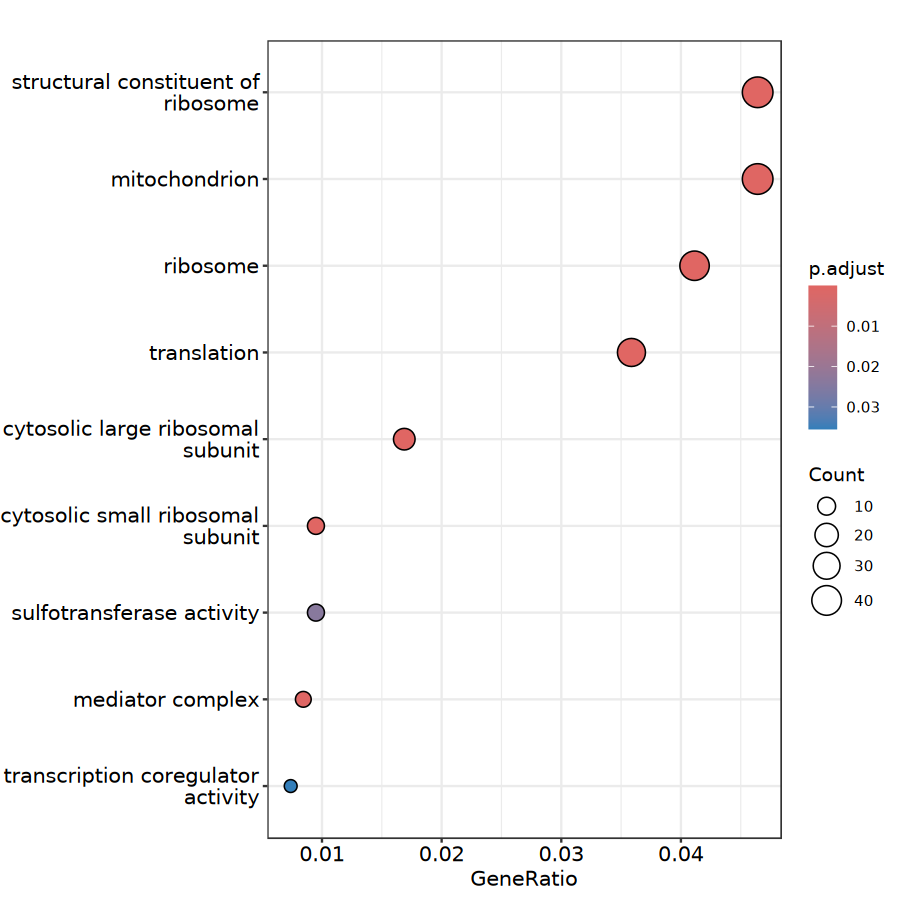

In [11]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

# brown 
target_genes <- geneInfo %>%
  filter(ModuleColor == "yellow") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
yellow_res <- as.data.frame(ego_custom) %>% mutate(module = 'yellow')

# View results
dotplot(ego_custom)

### turquoise module
neg correlated with tissue and shell growth, pos correlated with phase 2 temp

neg correlated with phase 2 hypoxia and pos correlated with phase 2 both
- lower expression in phase 2 hypoxia compared to control, warm, both
- higher expression in phase 2 both compared to control, hypoxia, warm

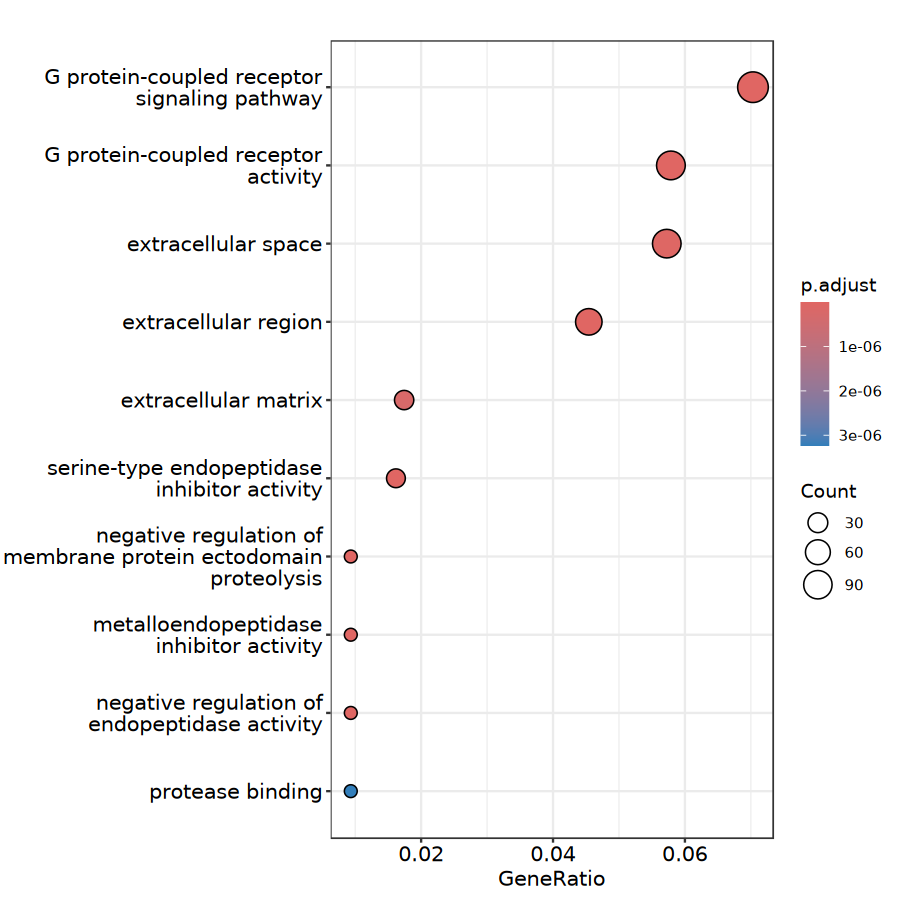

In [12]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "turquoise") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
turq_res <- as.data.frame(ego_custom) %>% mutate(module = 'turquoise')

# View results
dotplot(ego_custom)

### red module
neg correlated with shell and tissue growth, pos correlation with phase 2 interaction

neg correlated with phase 2 both
- lower expression in phase 2 both compared to control, hympoxia, warm

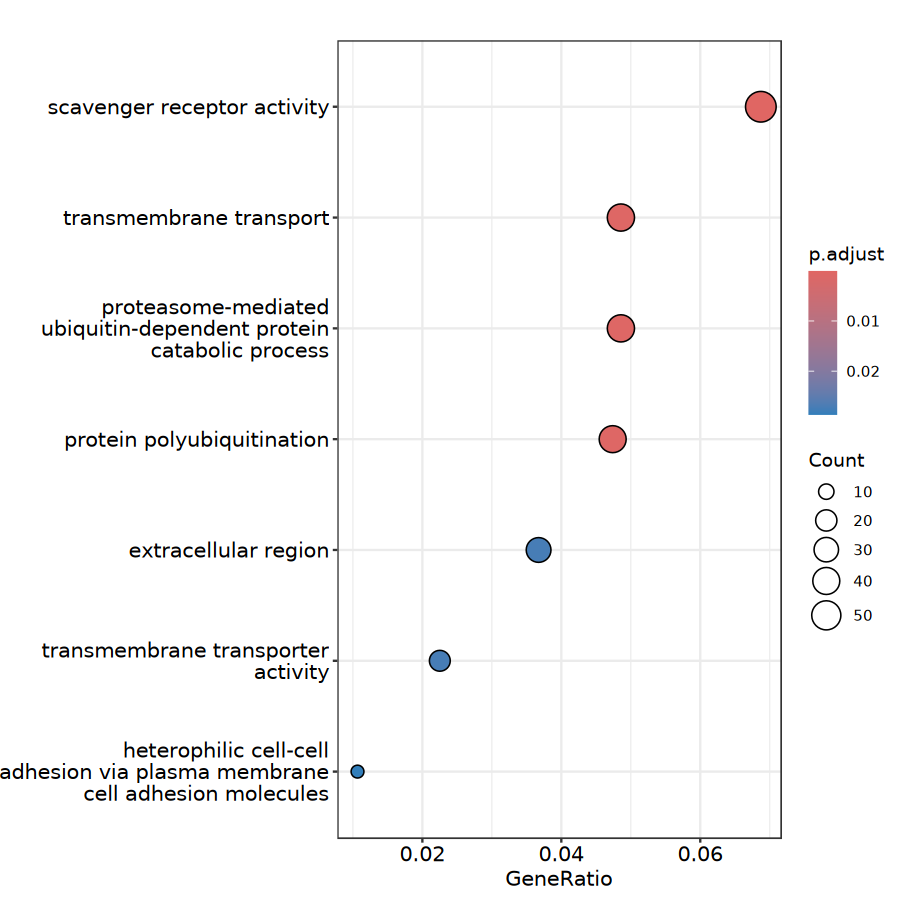

In [13]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "red") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
red_res <- as.data.frame(ego_custom) %>% mutate(module = 'red')

# View results
dotplot(ego_custom)

### salmon module
neg correlated with phase 1 warm
- lower expression in phase warm compared to control, hypoxia, both

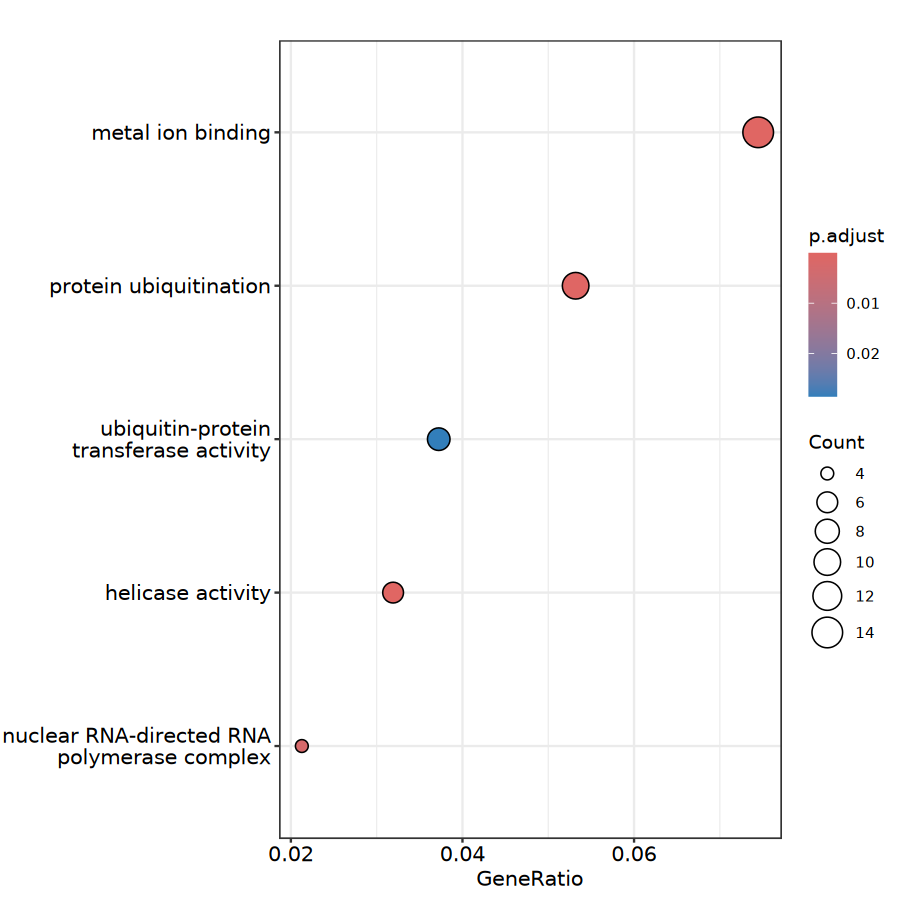

In [14]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "salmon") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
salmon_res <- as.data.frame(ego_custom) %>% mutate(module = 'salmon')

# View results
dotplot(ego_custom)

### purple module
neg correlated with phase 1 temp

neg correlated with phase 1 warm

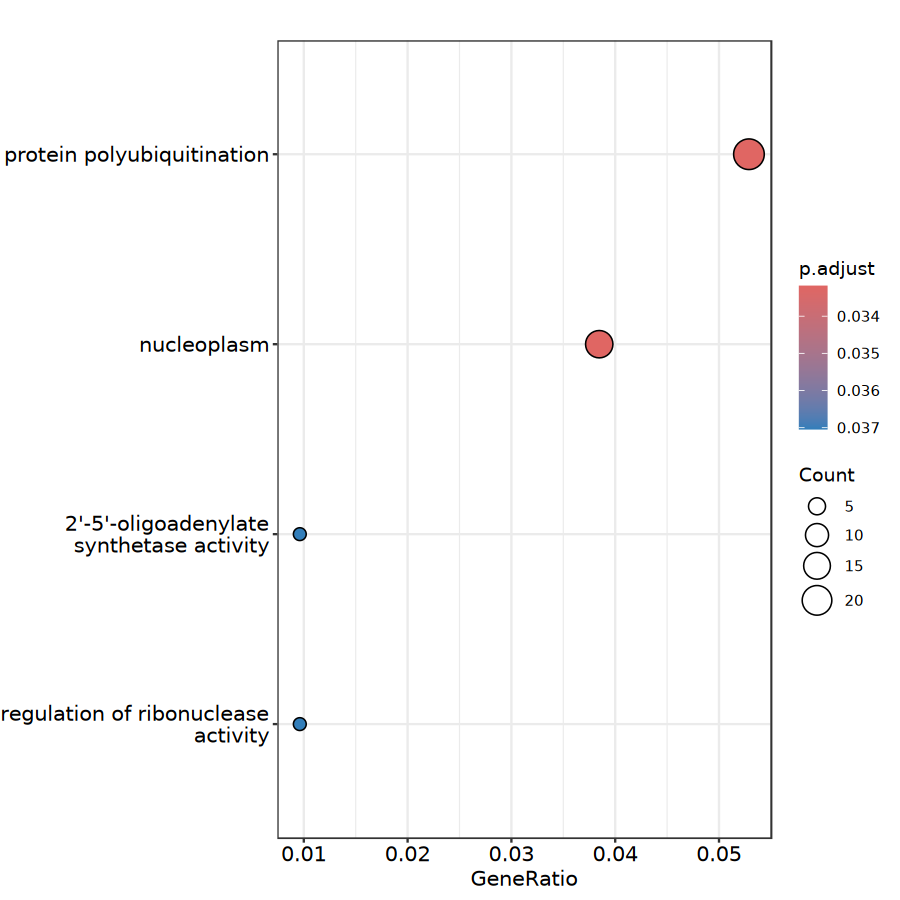

In [15]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "purple") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
purple_res <- as.data.frame(ego_custom) %>% mutate(module = 'purple')

# View results
dotplot(ego_custom)

### pink module
pos correlated with phase 2 interaction 

pos correlated with phase 2 both 
- higher expression in phase 2 both compared to control, warm, hypoxia

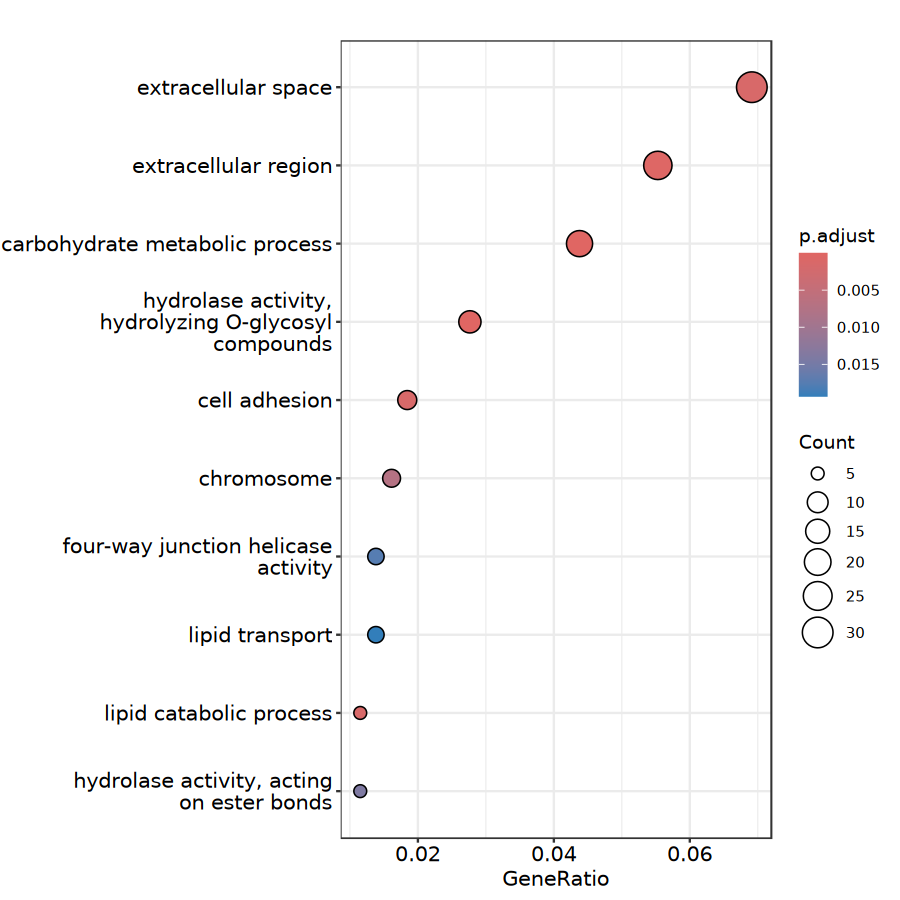

In [16]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "pink") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
pink_res <- as.data.frame(ego_custom) %>% mutate(module = 'pink')

# View results
dotplot(ego_custom)

### midnightblue module
neg correlation with shell growth, pos correlation with phase 2 interaction, phase 2 temp, and phase 2 DO

neg correlated with phase 2 control
- lower expression in phase 2 control compared to warm, hypoxia, both
neg correlated with phase 2 both
- lower expression in phase 2 both compared to warm, hypoxia, control

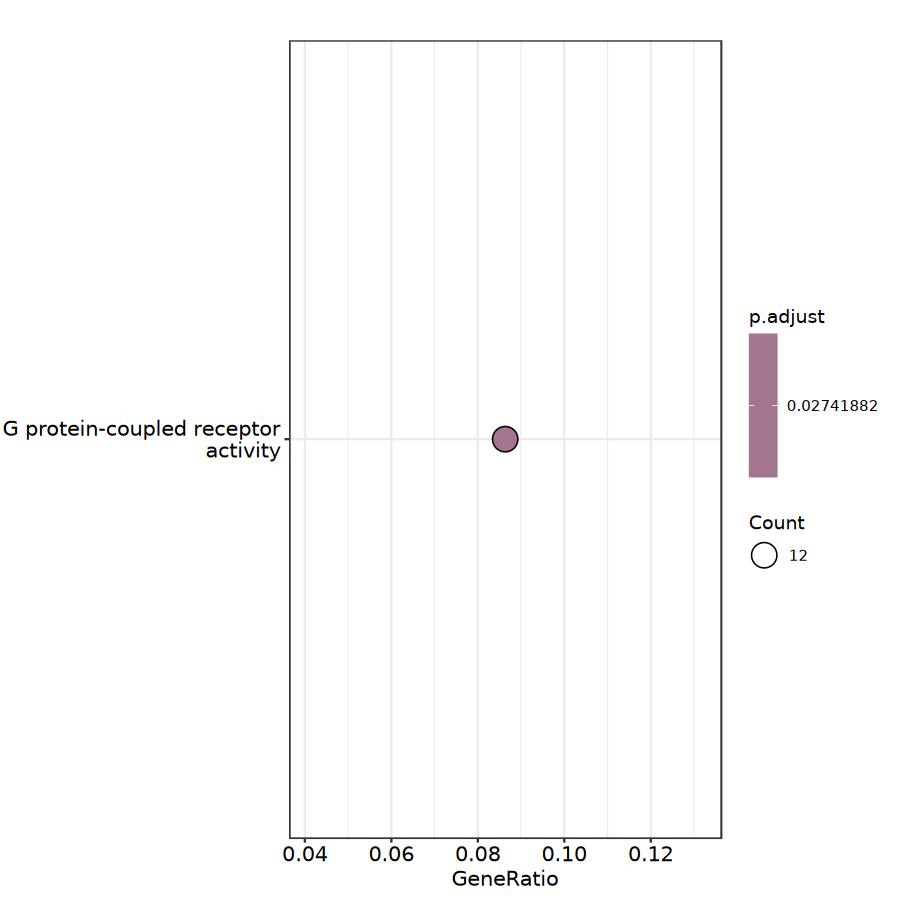

In [17]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "midnightblue") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
midnightblue_res <- as.data.frame(ego_custom) %>% mutate(module = 'midnightblue')

# View results
dotplot(ego_custom)

### magenta module
pos correlated with phase 2 both
- higher expression in phase 2 both compared to control, warm, and hypoxic

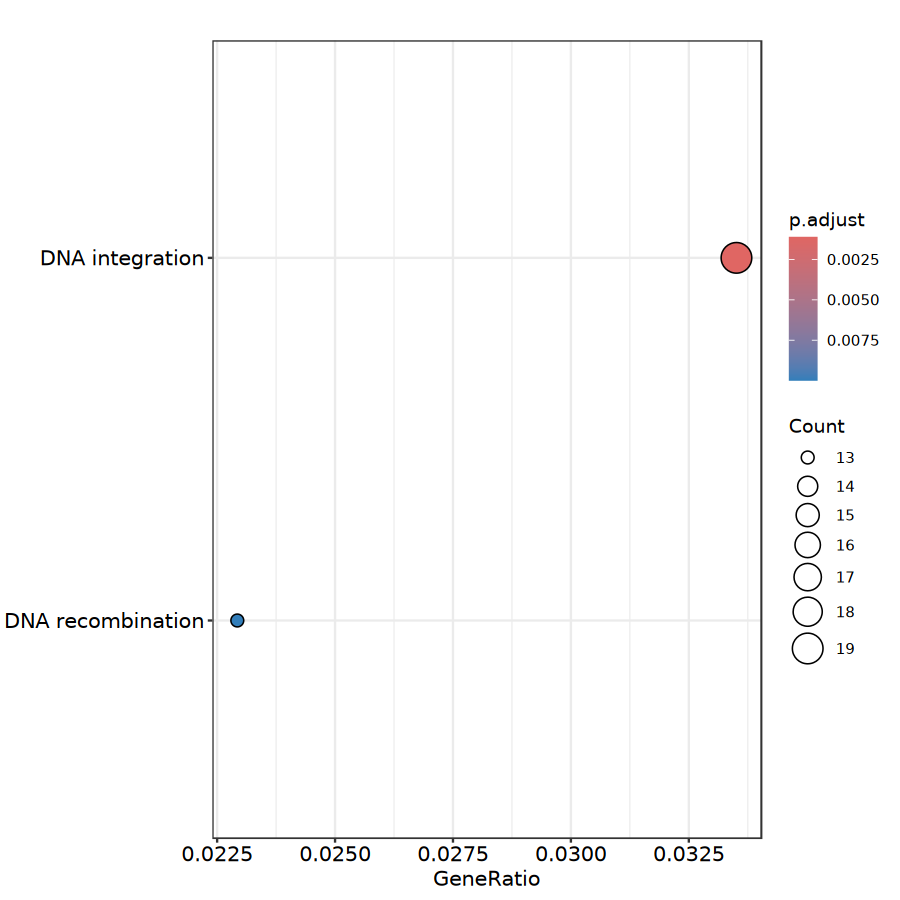

In [18]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "magenta") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
magenta_res <- as.data.frame(ego_custom) %>% mutate(module = 'magenta')

# View results
dotplot(ego_custom)

### lightcyan module
pos correlation with shell growth, neg correlation with phase 2 interaction and phase 2 temp

pos correlated with phase 2 control and phase 2 hypoxia, neg correlated with phase 2 both
- higher expression in phase 2 control oysters compared to hypoxia, control, and both
- higher expression in phase 2 hypoxia oysters compared to warm, control, and both
- lower expression in phpase 2 both compared to warm, hypoxia, control

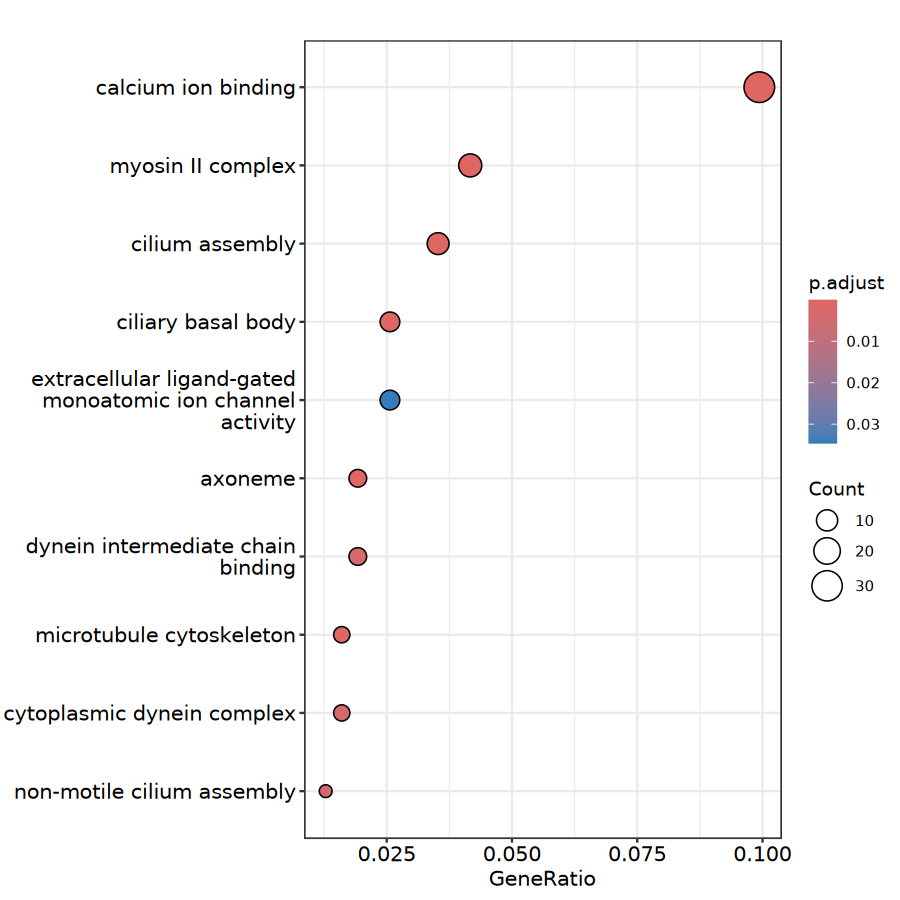

In [19]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "lightcyan") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
lightcyan_res <- as.data.frame(ego_custom) %>% mutate(module = 'lightcyan')

# View results
dotplot(ego_custom)

### green module
neg correlated with phase 2 control, pos correlated with phase 2 warm and hypoxic

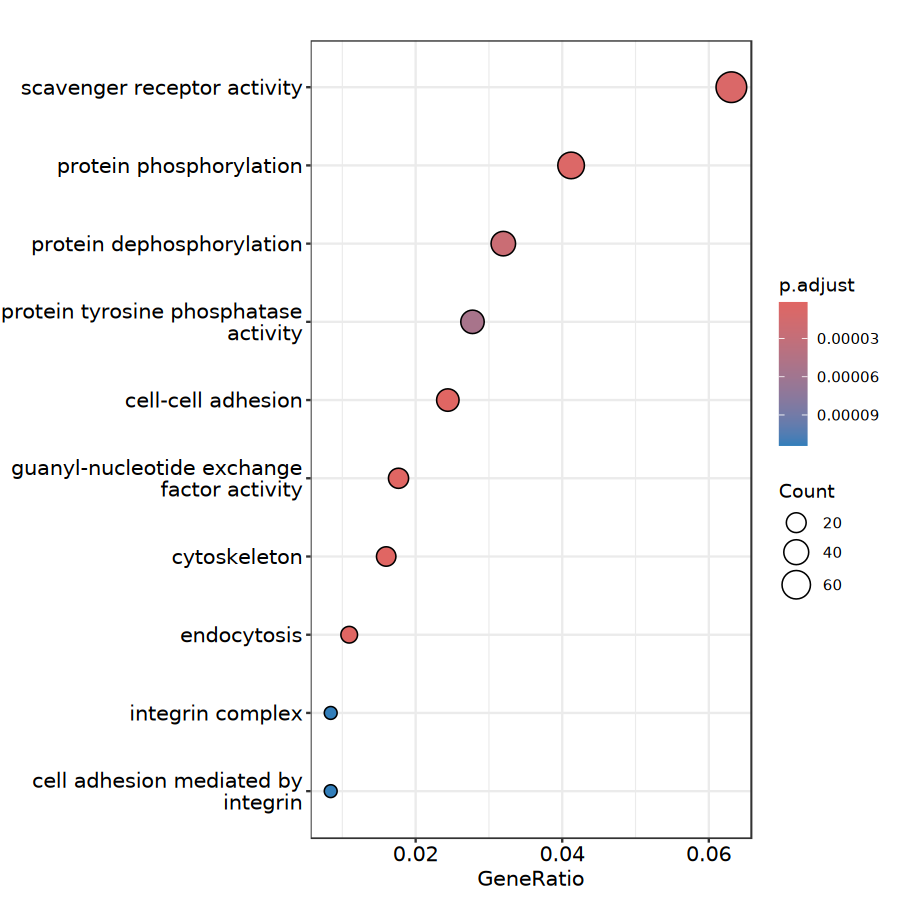

In [20]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "green") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
green_res <- as.data.frame(ego_custom) %>% mutate(module = 'green')

# View results
dotplot(ego_custom)

### brown module
pos correlated with phase 2 hypoxic, neg correlated with phase 2 both

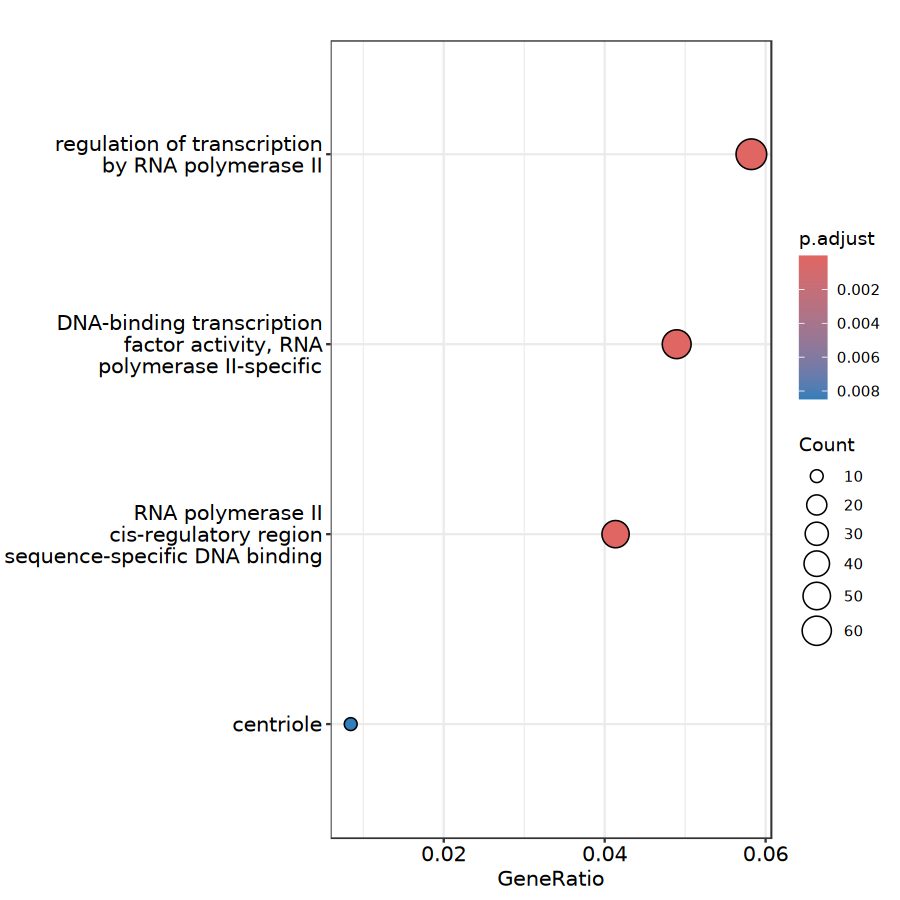

In [21]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "brown") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
brown_res <- as.data.frame(ego_custom) %>% mutate(module = 'brown')

# View results
dotplot(ego_custom)

### cyan module
neg correlation with tissue:shell growth

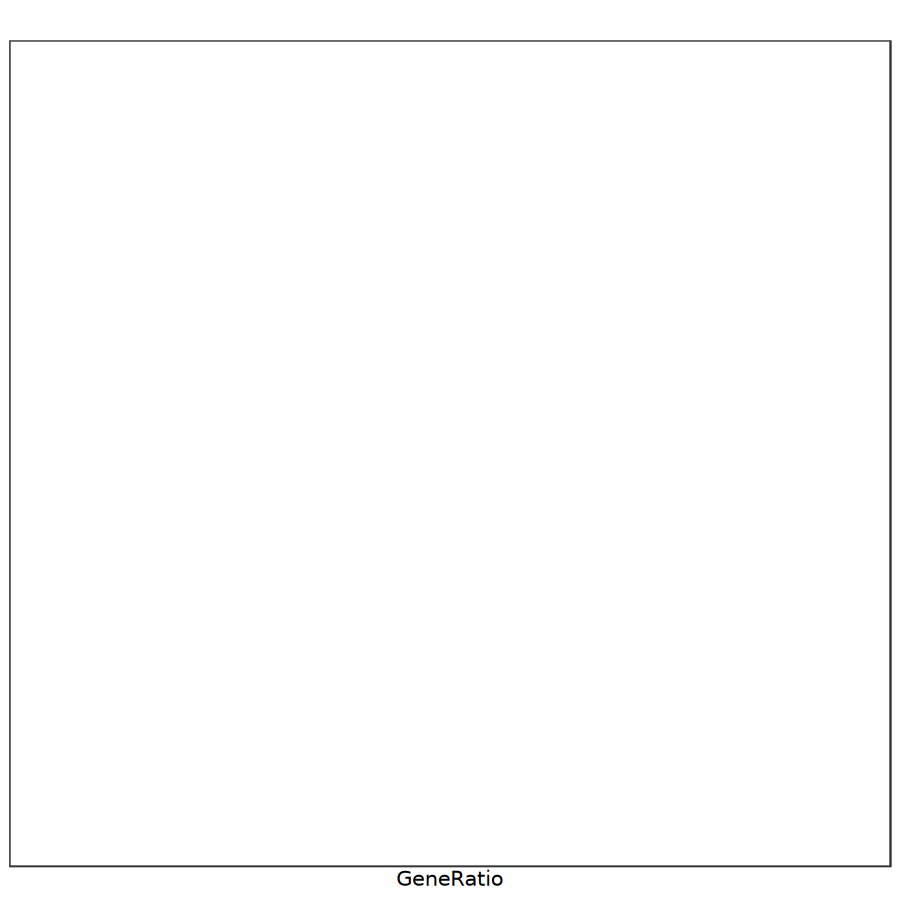

In [22]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "cyan") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
cyan_res <- as.data.frame(ego_custom) %>% mutate(module = 'cyan')

# View results
dotplot(ego_custom)

no enriched GO terms

### blue module
pos correlation with shell and tissue growth, neg correlation with phase 2 interaction, phase 2 temp, and phase 2 DO

pos correlated with phase 2 control, neg correlated with phase 2 warm

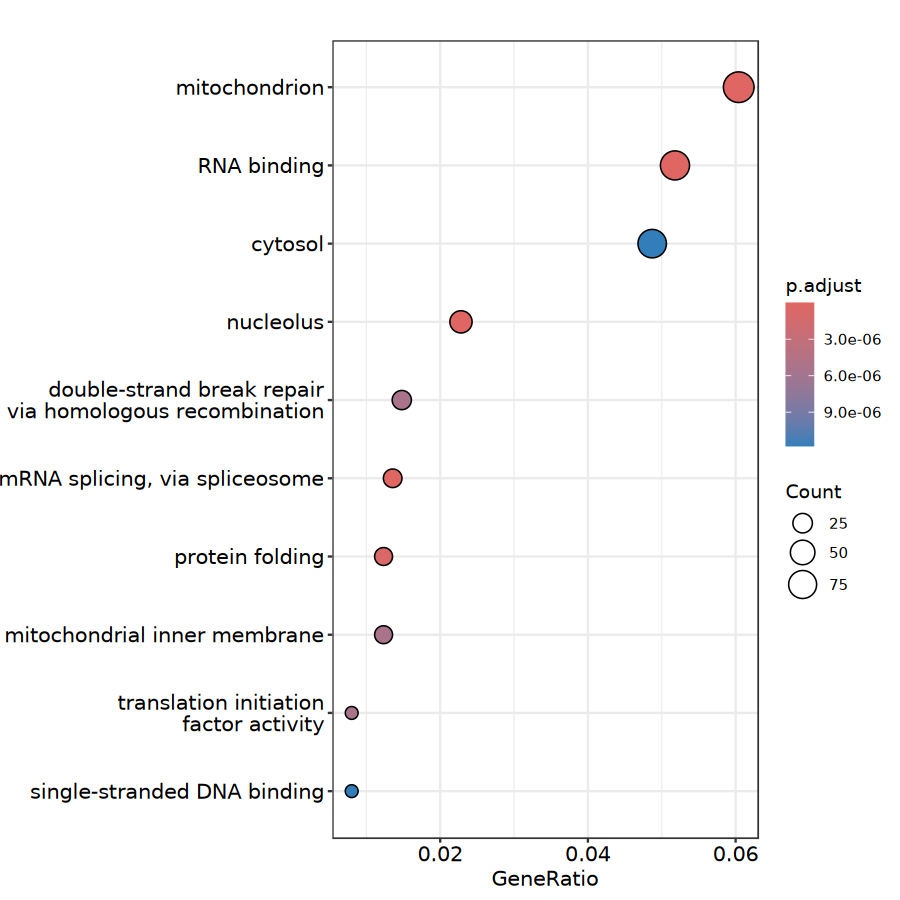

In [23]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "blue") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
blue_res <- as.data.frame(ego_custom) %>% mutate(module = 'blue')

# View results
dotplot(ego_custom)

### black module
neg correlation with shell and tissue growth, pos correlation with phase 2 interaction, phase 2 temp, and phase 2 DO (opposite of blue module)

neg correlated with phase 2 control, pos correlated with phase 2 both

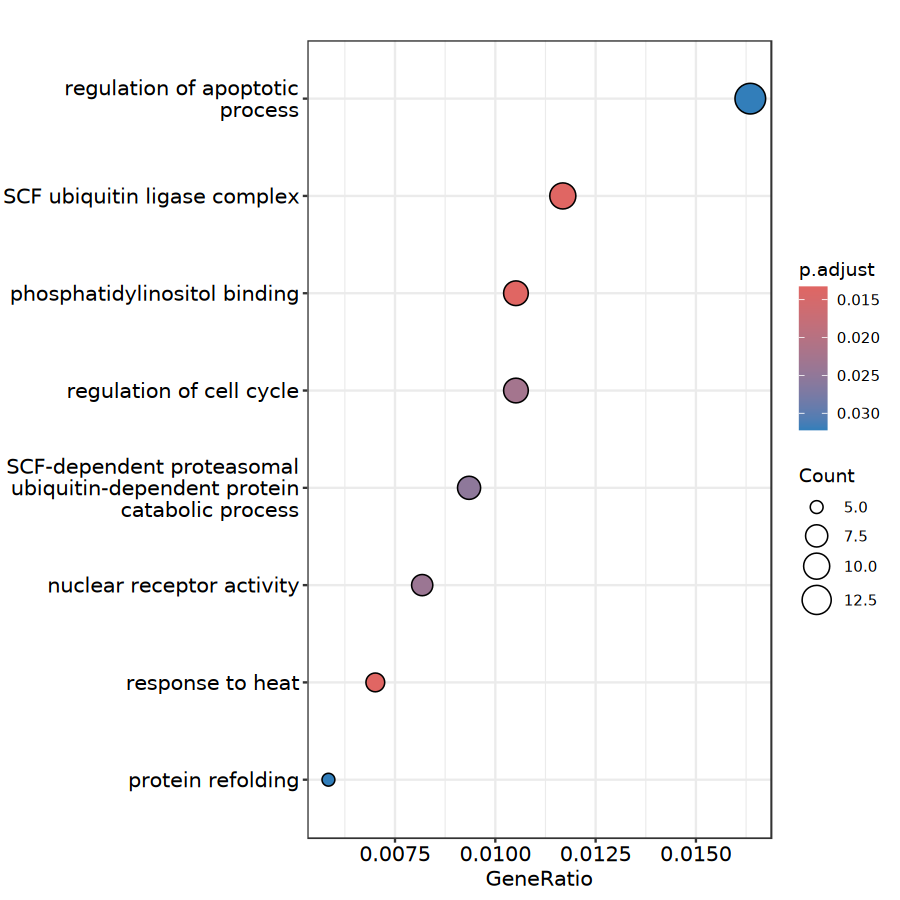

In [24]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "black") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
black_res <- as.data.frame(ego_custom) %>% mutate(module = 'black')


# View results
dotplot(ego_custom)

## 3. Plot module enrichment

### all sig modules

In [25]:
mod.all <- rbind(yellow_res, turq_res, red_res, salmon_res, purple_res, pink_res, midnightblue_res, magenta_res,
                lightcyan_res, green_res, brown_res, cyan_res, blue_res, black_res)
head(mod.all)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,module
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0003735,GO:0003735,structural constituent of ribosome,44/948,66/10514,1.091707e-30,3.853727e-28,3.849704e-28,LOC111100708/LOC111103150/LOC111103170/LOC111104145/LOC111104388/LOC111106383/LOC111111438/LOC111112701/LOC111114067/LOC111118104/LOC111118248/LOC111118348/LOC111118510/LOC111119040/LOC111119071/LOC111121601/LOC111126882/LOC111127437/LOC111128009/LOC111128024/LOC111128317/LOC111128580/LOC111128745/LOC111129410/LOC111130094/LOC111130218/LOC111132297/LOC111132903/LOC111133720/LOC111134500/LOC111135077/LOC111135100/LOC111135345/LOC111135849/LOC111136247/LOC111136411/LOC111136425/LOC144619705/LOC144620609/LOC144620712/LOC144621283/LOC144622911/LOC144624247/LOC144627618,44,yellow
GO:0005840,GO:0005840,ribosome,39/948,53/10514,5.975391e-30,1.054656e-27,1.053556e-27,LOC111100708/LOC111103170/LOC111104145/LOC111104388/LOC111106383/LOC111111438/LOC111112701/LOC111114067/LOC111118104/LOC111118248/LOC111118348/LOC111118510/LOC111119040/LOC111119071/LOC111121601/LOC111126882/LOC111127437/LOC111128009/LOC111128024/LOC111128317/LOC111128580/LOC111128745/LOC111129410/LOC111130094/LOC111130218/LOC111132297/LOC111132903/LOC111133720/LOC111135077/LOC111135849/LOC111136247/LOC111136411/LOC111136425/LOC144619705/LOC144620609/LOC144620712/LOC144621283/LOC144622911/LOC144627618,39,yellow
GO:0006412,GO:0006412,translation,34/948,52/10514,1.487619e-23,1.750432e-21,1.748605e-21,LOC111100708/LOC111103170/LOC111104145/LOC111104388/LOC111106383/LOC111111438/LOC111114067/LOC111118104/LOC111118248/LOC111118348/LOC111118510/LOC111119040/LOC111119071/LOC111121601/LOC111126882/LOC111127437/LOC111128009/LOC111128024/LOC111128317/LOC111128580/LOC111129410/LOC111130094/LOC111130218/LOC111132903/LOC111133720/LOC111135077/LOC111135849/LOC111136411/LOC111136425/LOC144620609/LOC144620712/LOC144621283/LOC144622911/LOC144624247,34,yellow
GO:0022625,GO:0022625,cytosolic large ribosomal subunit,16/948,17/10514,2.647790e-16,2.336675e-14,2.334236e-14,LOC111103150/LOC111103170/LOC111118104/LOC111119071/LOC111121601/LOC111127437/LOC111128745/LOC111132297/LOC111133720/LOC111134500/LOC111135345/LOC111135849/LOC111136247/LOC144620609/LOC144622911/LOC144627618,16,yellow
GO:0022627,GO:0022627,cytosolic small ribosomal subunit,9/948,11/10514,1.769519e-08,1.249280e-06,1.247976e-06,LOC111100708/LOC111104388/LOC111114067/LOC111119040/LOC111126882/LOC111128317/LOC111128580/LOC144619705/LOC144620712,9,yellow
GO:0005739,GO:0005739,mitochondrion,44/948,239/10514,3.301799e-06,1.942559e-04,1.940531e-04,LOC111103072/LOC111103250/LOC111104128/LOC111104702/LOC111105388/LOC111105598/LOC111105879/LOC111107699/LOC111110359/LOC111112266/LOC111113204/LOC111114527/LOC111116418/LOC111116974/LOC111117976/LOC111118461/LOC111118593/LOC111118872/LOC111120712/LOC111121504/LOC111121719/LOC111127001/LOC111128123/LOC111128157/LOC111128302/LOC111128323/LOC111128659/LOC111128742/LOC111128795/LOC111129409/LOC111130026/LOC111130282/LOC111130608/LOC111130738/LOC111133170/LOC111133413/LOC111134951/LOC111135130/LOC111135526/LOC111136411/LOC144620328/LOC144620891/LOC144623752/LOC144625632,44,yellow


what if we remove GO terms - look at just GOSlim categories

In [26]:
mod.all$GeneRatio <- sapply(strsplit(mod.all$GeneRatio, "/"), function(x) {
  as.numeric(x[1]) / as.numeric(x[2])
})

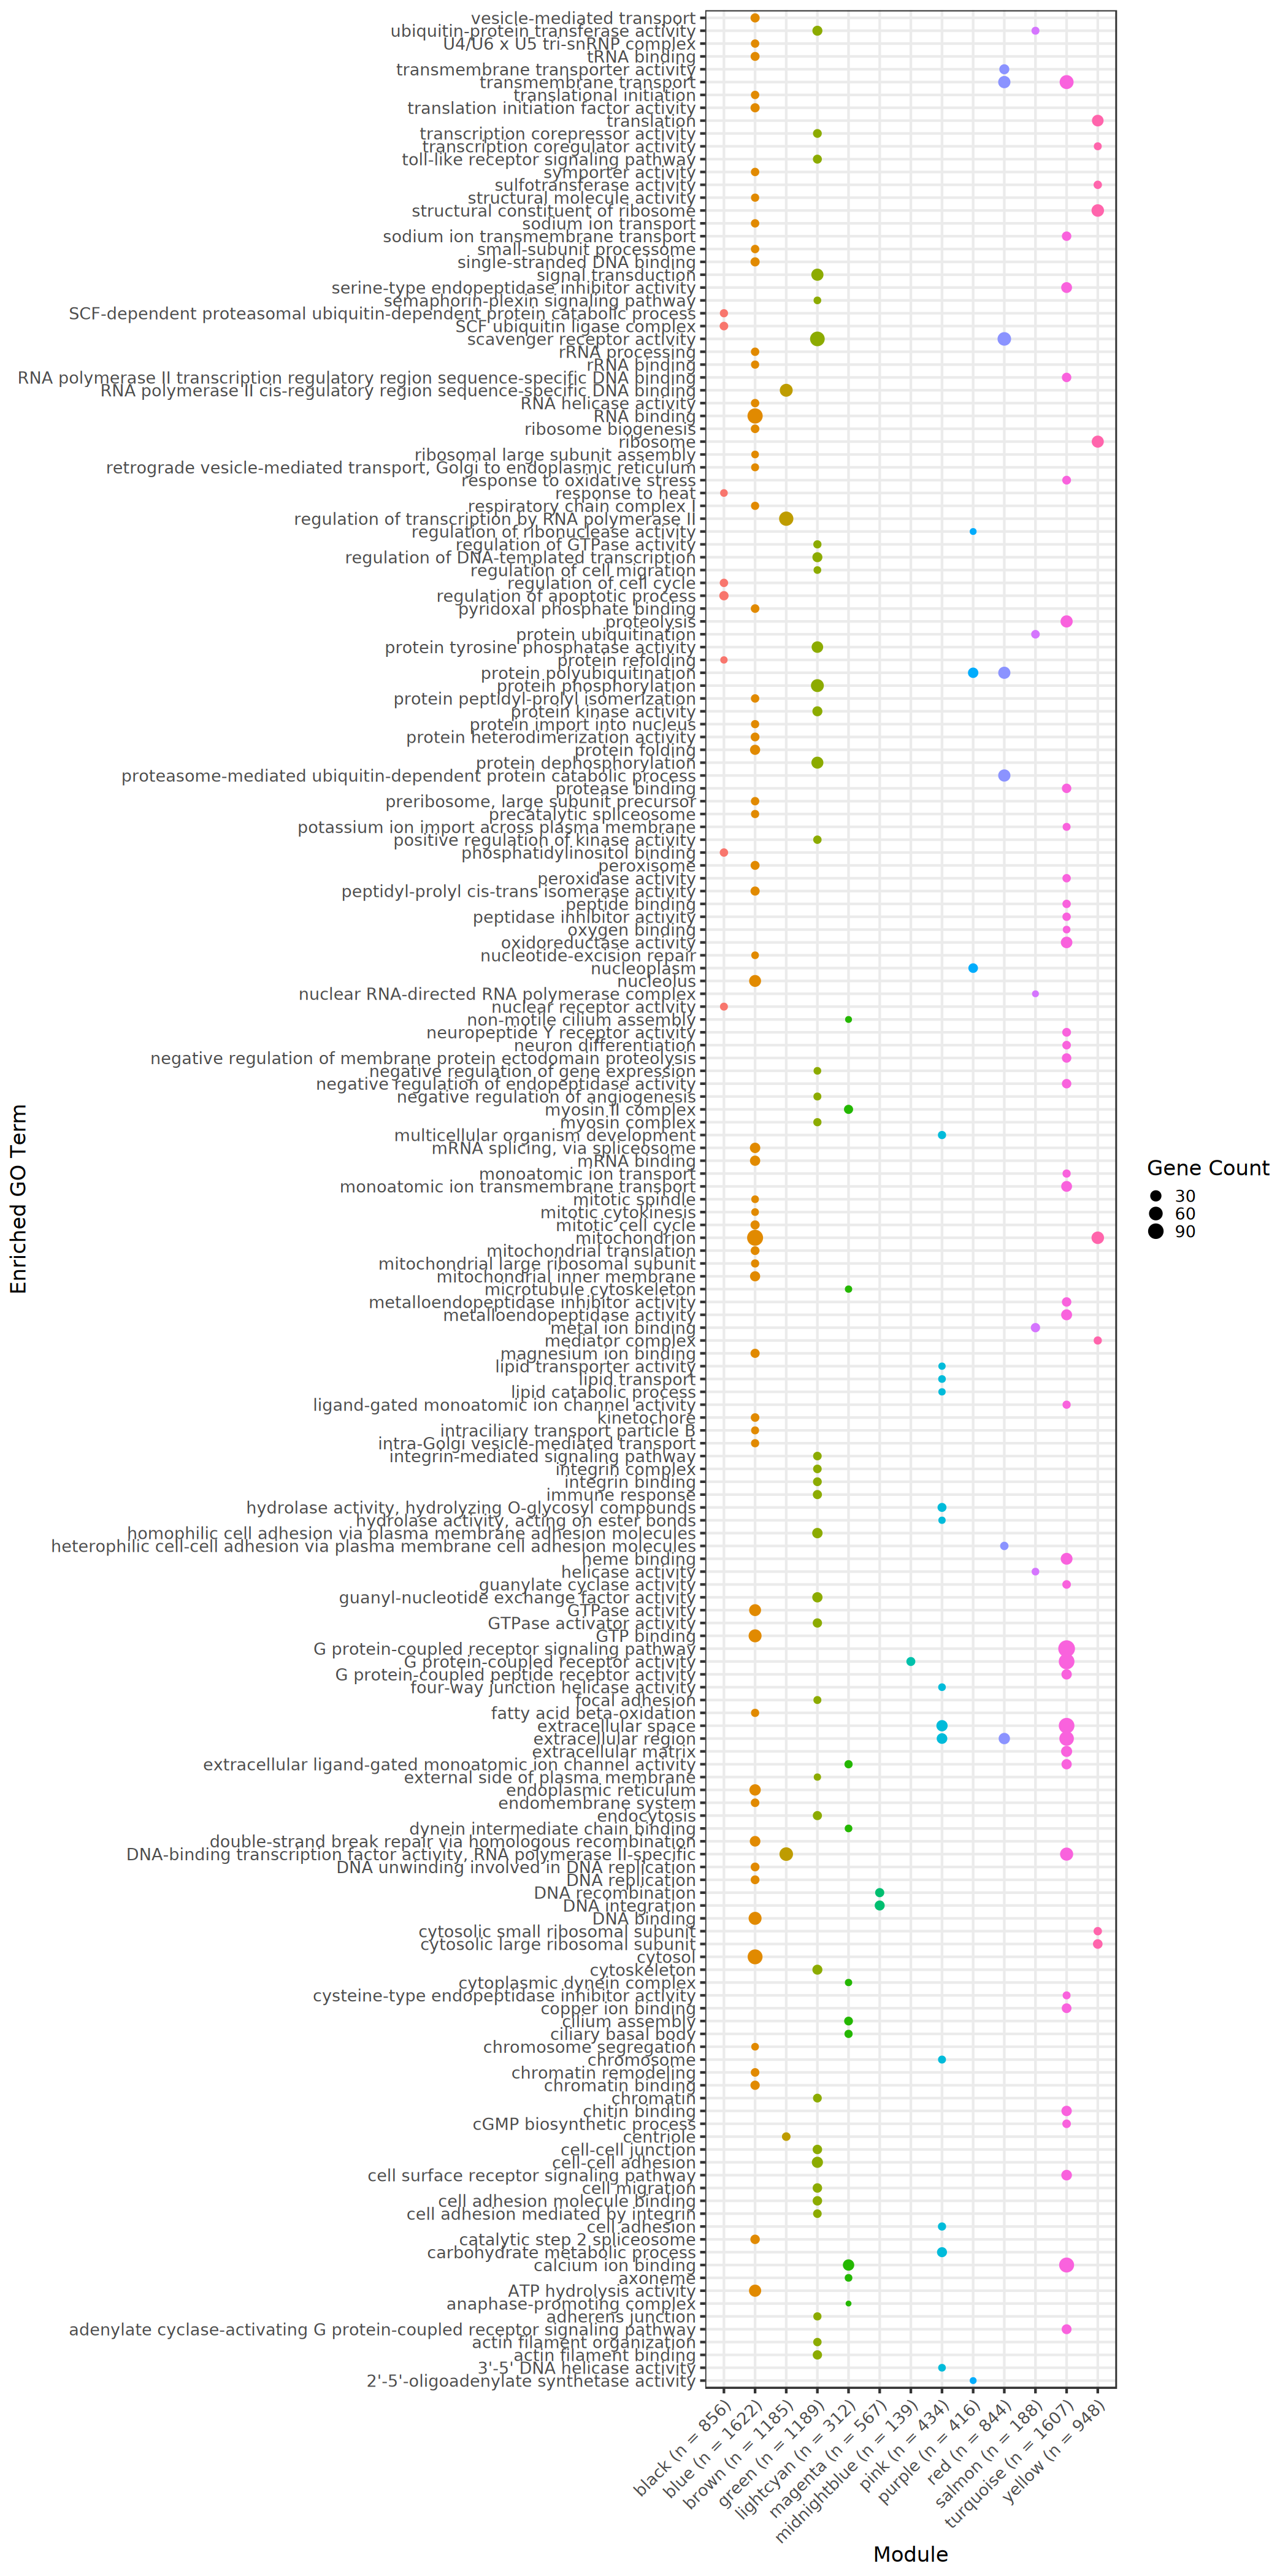

In [27]:
options(repr.plot.height = 35, repr.plot.width = 17.5)

module_gene_counts <- geneInfo %>%
  dplyr::count(ModuleColor)

module_labels <- setNames(
  paste0(module_gene_counts$ModuleColor, " (n = ", module_gene_counts$n, ")"),
  module_gene_counts$ModuleColor
)

ggplot(mod.all, aes(
  x = module,
  y = Description,
  size = Count,
  color = module
)) +
  guides(color = 'none') +
  #scale_color_manual(values = c('black', 'blue', 'red')) +
  scale_x_discrete(labels = module_labels) +
  geom_point() +
  labs(
    x = "Module",
    y = "Enriched GO Term",
    size = "Gene Count"
  ) +
  theme_bw(base_size = 20) +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

#### adding GOslim

In [38]:
mod.mapped <- mod.all %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
mod.slim <- mod.mapped %>%
  filter(!is.na(GOSlim_Bin))

head(mod.slim)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,module,SlimID,GOSlim_Bin
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0005840,ribosome,0.041139241,53/10514,5.975391e-30,1.054656e-27,1.053556e-27,LOC111100708/LOC111103170/LOC111104145/LOC111104388/LOC111106383/LOC111111438/LOC111112701/LOC111114067/LOC111118104/LOC111118248/LOC111118348/LOC111118510/LOC111119040/LOC111119071/LOC111121601/LOC111126882/LOC111127437/LOC111128009/LOC111128024/LOC111128317/LOC111128580/LOC111128745/LOC111129410/LOC111130094/LOC111130218/LOC111132297/LOC111132903/LOC111133720/LOC111135077/LOC111135849/LOC111136247/LOC111136411/LOC111136425/LOC144619705/LOC144620609/LOC144620712/LOC144621283/LOC144622911/LOC144627618,39,yellow,GO:0005840,ribosome
GO:0005739,mitochondrion,0.046413502,239/10514,3.301799e-06,1.942559e-04,1.940531e-04,LOC111103072/LOC111103250/LOC111104128/LOC111104702/LOC111105388/LOC111105598/LOC111105879/LOC111107699/LOC111110359/LOC111112266/LOC111113204/LOC111114527/LOC111116418/LOC111116974/LOC111117976/LOC111118461/LOC111118593/LOC111118872/LOC111120712/LOC111121504/LOC111121719/LOC111127001/LOC111128123/LOC111128157/LOC111128302/LOC111128323/LOC111128659/LOC111128742/LOC111128795/LOC111129409/LOC111130026/LOC111130282/LOC111130608/LOC111130738/LOC111133170/LOC111133413/LOC111134951/LOC111135130/LOC111135526/LOC111136411/LOC144620328/LOC144620891/LOC144623752/LOC144625632,44,yellow,GO:0005739,mitochondrion
GO:0007186,G protein-coupled receptor signaling pathway,0.070317362,275/10514,1.034934e-25,4.232879e-23,3.605927e-23,LOC111099794/LOC111100130/LOC111103268/LOC111103785/LOC111104186/LOC111104484/LOC111104847/LOC111104858/LOC111105122/LOC111105369/LOC111105770/LOC111105782/LOC111105808/LOC111106027/LOC111106352/LOC111107321/LOC111107362/LOC111110409/LOC111110420/LOC111110431/LOC111110886/LOC111110890/LOC111110917/LOC111111622/LOC111112009/LOC111112034/LOC111112680/LOC111113548/LOC111114143/LOC111114171/LOC111114261/LOC111116095/LOC111116167/LOC111116725/LOC111118001/LOC111118133/LOC111118237/LOC111118478/LOC111118486/LOC111118494/LOC111118615/LOC111118671/LOC111118688/LOC111118709/LOC111118787/LOC111119095/LOC111119111/LOC111120815/LOC111121181/LOC111121320/LOC111121449/LOC111121483/LOC111121615/LOC111121622/LOC111121638/LOC111124959/LOC111125383/LOC111126548/LOC111126697/LOC111126782/LOC111126791/LOC111126861/LOC111126929/LOC111126938/LOC111127050/LOC111127078/LOC111127476/LOC111127557/LOC111127955/LOC111128058/LOC111128485/LOC111128578/LOC111128614/LOC111128799/LOC111128854/LOC111128946/LOC111129334/LOC111129401/LOC111129475/LOC111130027/LOC111130376/LOC111130789/LOC111130804/LOC111132378/LOC111133370/LOC111133412/LOC111133681/LOC111133698/LOC111133844/LOC111133848/LOC111133995/LOC111134067/LOC111134122/LOC111134199/LOC111134273/LOC111135090/LOC111138225/LOC111138485/LOC144617484/LOC144619497/LOC144619589/LOC144619736/LOC144619850/LOC144621098/LOC144622277/LOC144623044/LOC144623173/LOC144624076/LOC144624154/LOC144626704/LOC144627042/LOC144627485/LOC144627497,113,turquoise,GO:0023052,signaling
GO:0005576,extracellular region,0.045426260,208/10514,8.372780e-13,1.141489e-10,9.724177e-11,LOC111099862/LOC111100180/LOC111100662/LOC111104838/LOC111105722/LOC111105727/LOC111106095/LOC111107119/LOC111107493/LOC111107498/LOC111107500/LOC111110365/LOC111110868/LOC111111165/LOC111111483/LOC111111604/LOC111111646/LOC111111656/LOC111111778/LOC111112854/LOC111114030/LOC111115607/LOC111115673/LOC111115803/LOC111115999/LOC111116198/LOC111116214/LOC111116684/LOC111117016/LOC111117191/LOC111117254/LOC111117426/LOC111117428/LOC111117464/LOC111117500/LOC111118377/LOC111118401/LOC111121724/LOC111125392/LOC111126687/LOC111126768/LOC111127657/LOC111128613/LOC111128799/LOC111129539/LOC111129707/LOC111132156/LOC111132220/LOC111132753/LOC111132808/LOC111132881/LOC111133222/LOC111133447/LOC111133553/LOC111134776/LOC111134788/LOC111135120/LOC111135614/LOC111138083/LOC111138403/LOC144617825/LOC144618404/LOC1

#### Module-Trait GO Enrichment

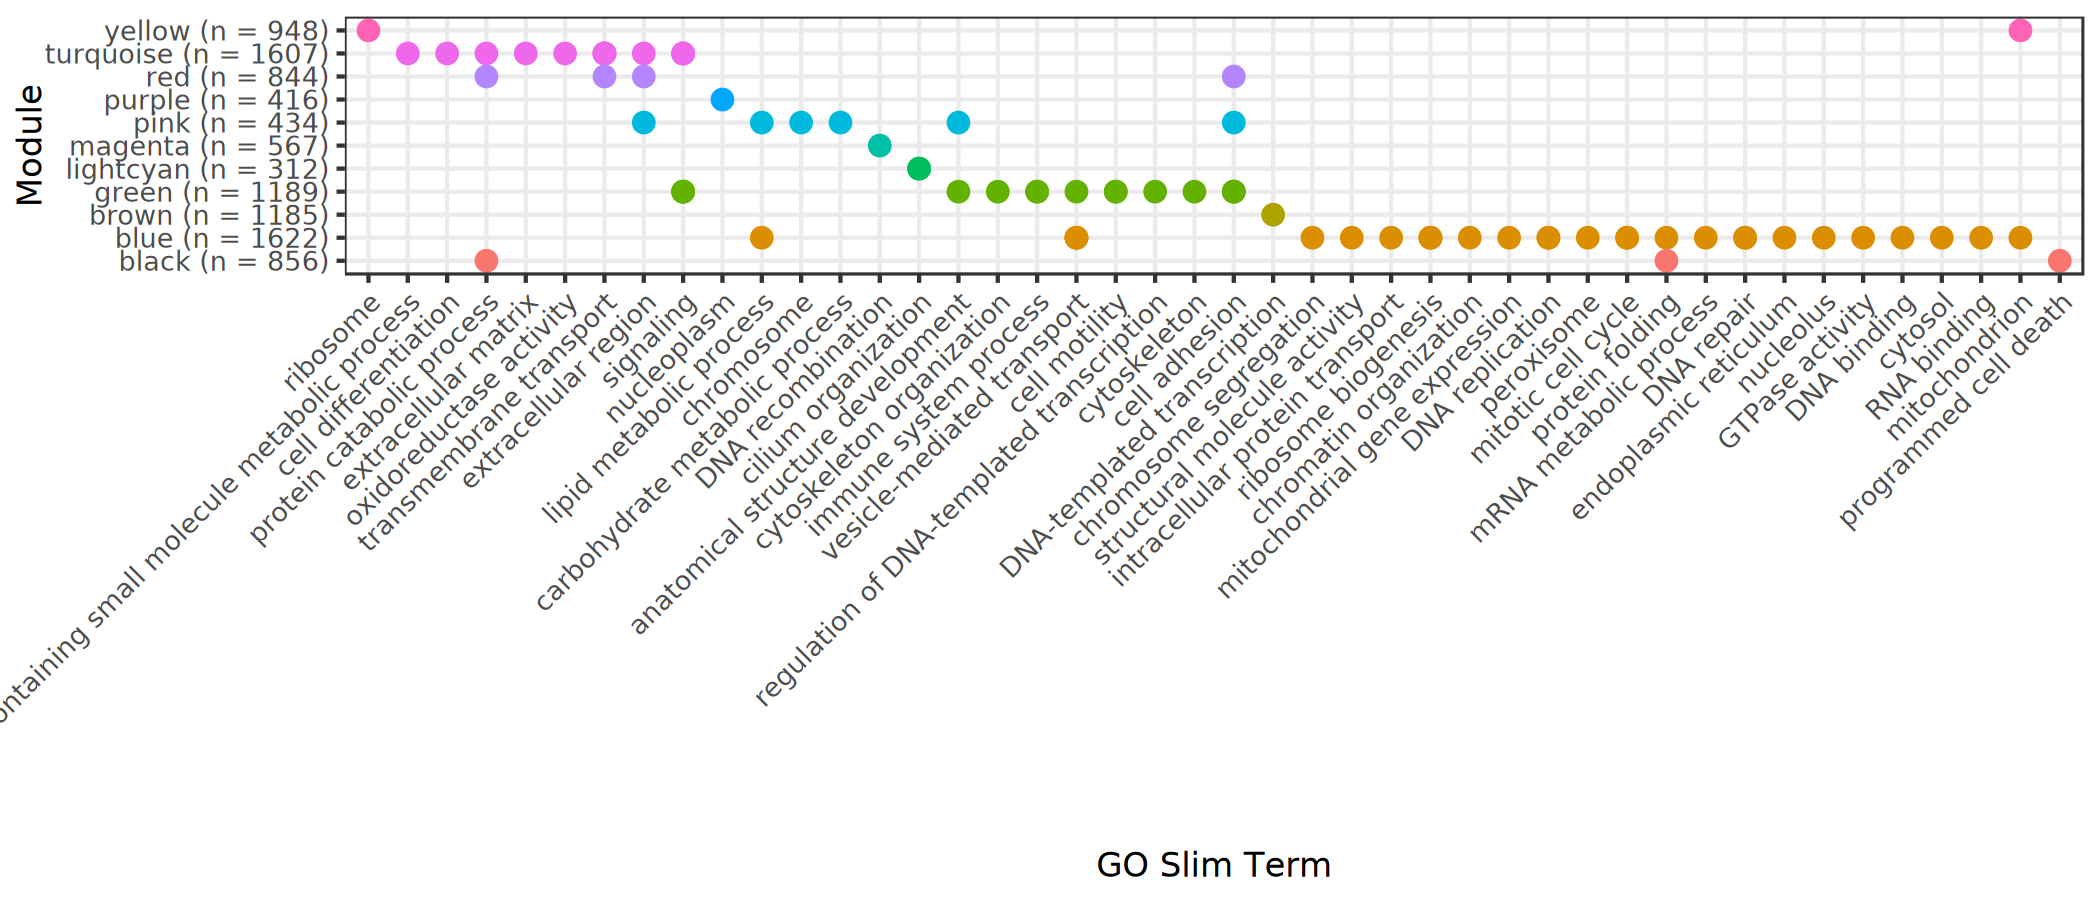

In [29]:
options(repr.plot.height = 7.5, repr.plot.width = 17.5)


# 1. set explicit module order
#module_order <- c("red", "black", "blue")   # put them in whatever order you want

#mod.slim <- mod.slim %>%
 # mutate(module = factor(module, levels = module_order))

# 2. order GOSlim_Bin by each bin's most significant module (respecting module_order for ties)
bin_order <- mod.slim %>%
  group_by(GOSlim_Bin) %>%
  slice_min(p.adjust, n = 1, with_ties = FALSE) %>%
  arrange(module, desc(Count)) %>%
  pull(GOSlim_Bin) %>%
  unique()

mod.slim2 <- mod.slim %>%
  mutate(GOSlim_Bin = factor(GOSlim_Bin, levels = rev(bin_order)))

# 3. update module_labels to match the new factor order (if not already matching)
#module_labels <- module_labels[module_order]

ggplot(mod.slim2, aes(
  x = module,
  y = GOSlim_Bin,
  color = module
)) +
  guides(color = 'none') +
 # scale_color_manual(values = c('red', 'black', 'blue'), drop = FALSE) +
  scale_x_discrete(labels = module_labels) +
  geom_point(size = 5) +
  labs(
    x = "Module",
    y = "GO Slim Term"
  ) +
  coord_flip() +
  theme_bw(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

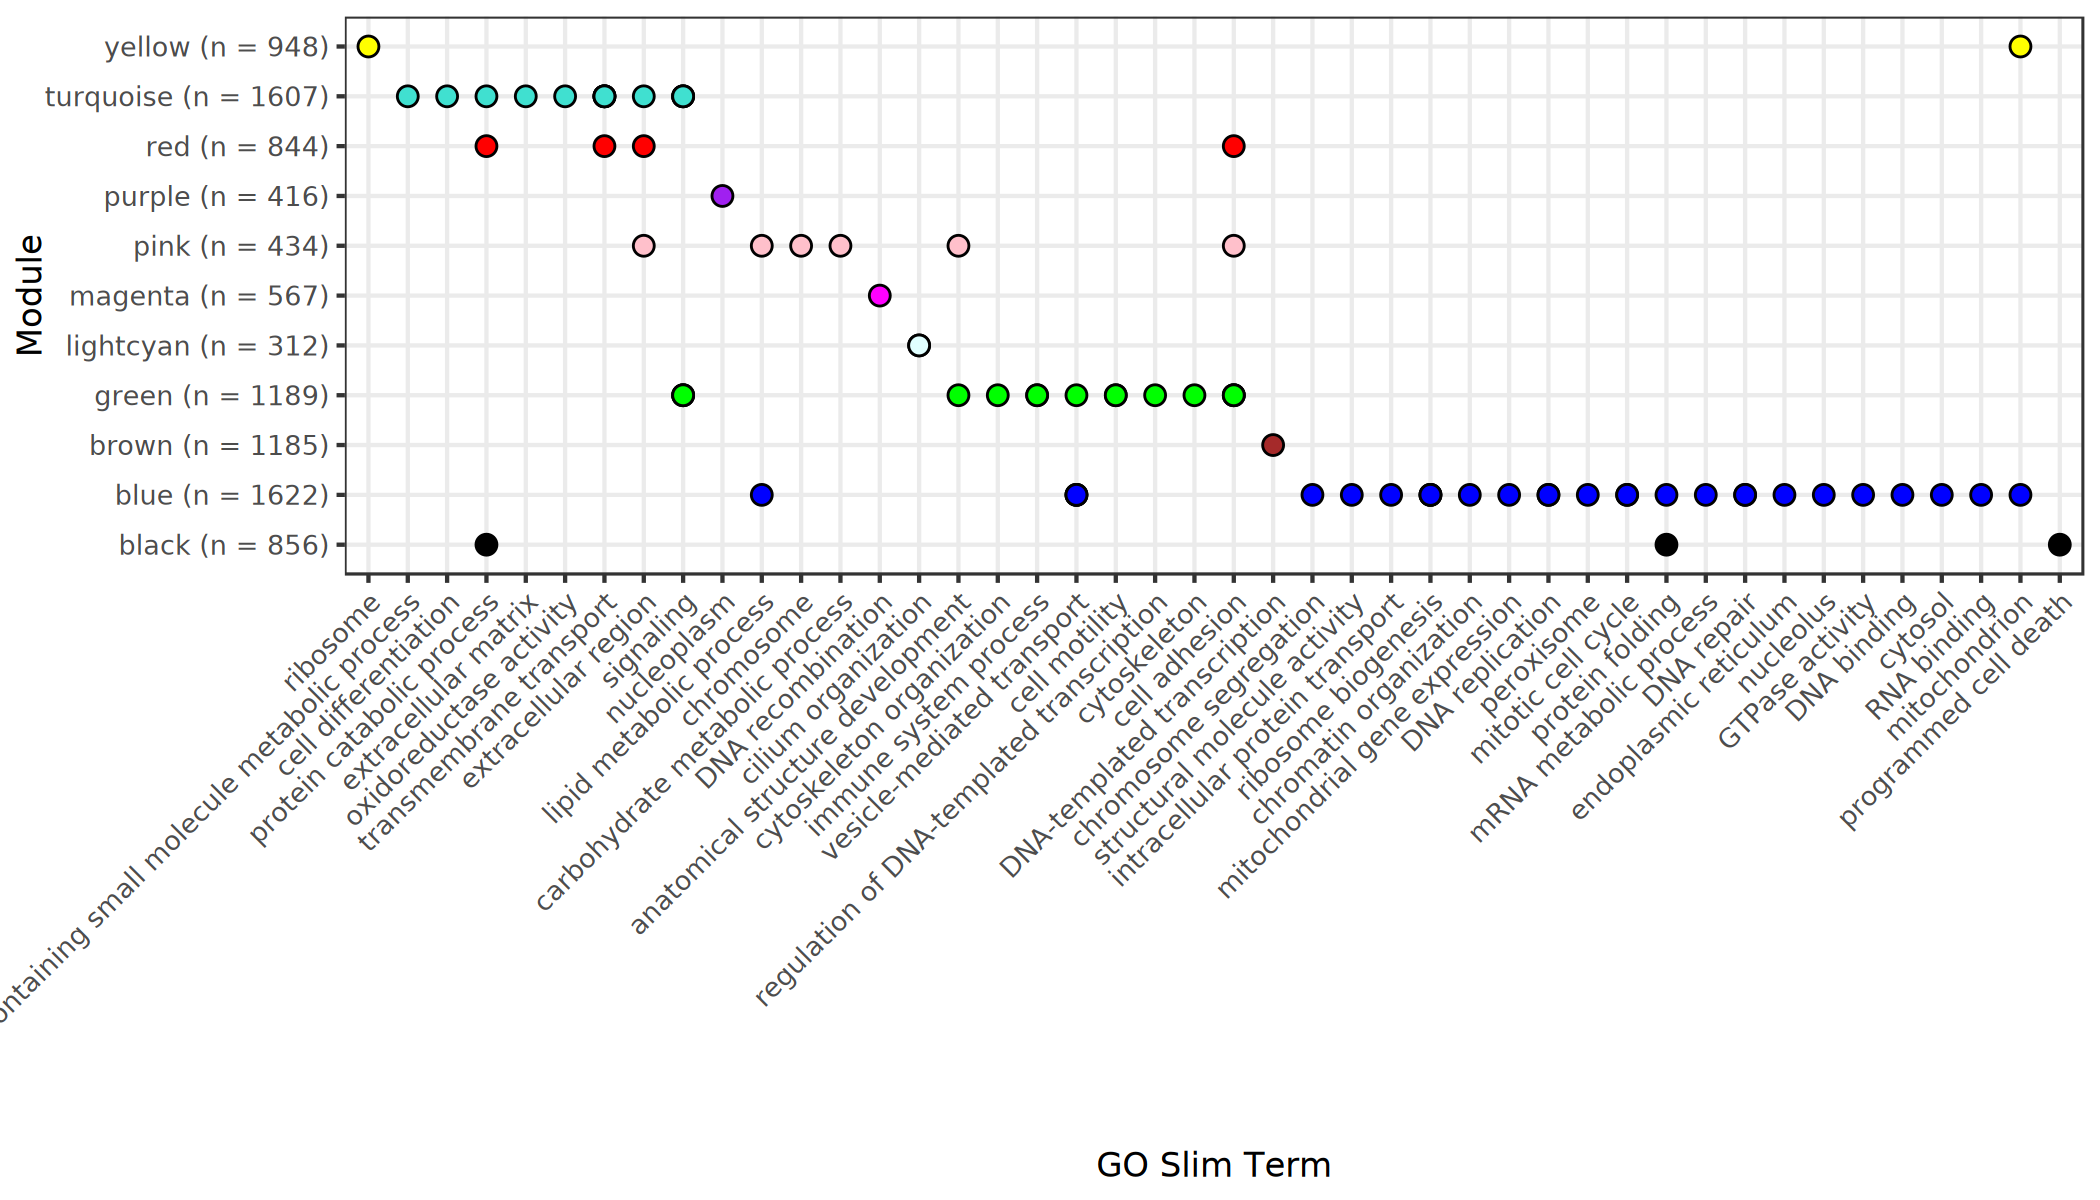

In [30]:
options(repr.plot.height = 10, repr.plot.width = 17.5)

# 1. Order GOSlim_Bin by the most significant module
bin_order <- mod.slim %>%
  group_by(GOSlim_Bin) %>%
  slice_min(p.adjust, n = 1, with_ties = FALSE) %>%
  arrange(module, desc(Count)) %>%
  pull(GOSlim_Bin) %>%
  unique()

# 2. Set GO Slim term order
mod.slim2 <- mod.slim %>%
  mutate(GOSlim_Bin = factor(GOSlim_Bin, levels = rev(bin_order)))

# 3. Plot
ggplot(mod.slim2, aes(
  x = module,
  y = GOSlim_Bin,
  fill = module
)) +
  guides(fill = "none") +
  scale_fill_identity() +
  scale_x_discrete(labels = module_labels) +
  geom_point(size = 5, col = 'black', shape = 21) +
  labs(
    x = "Module",
    y = "GO Slim Term"
  ) +
  coord_flip() +
  theme_bw(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

### Phase 2 Growth Modules

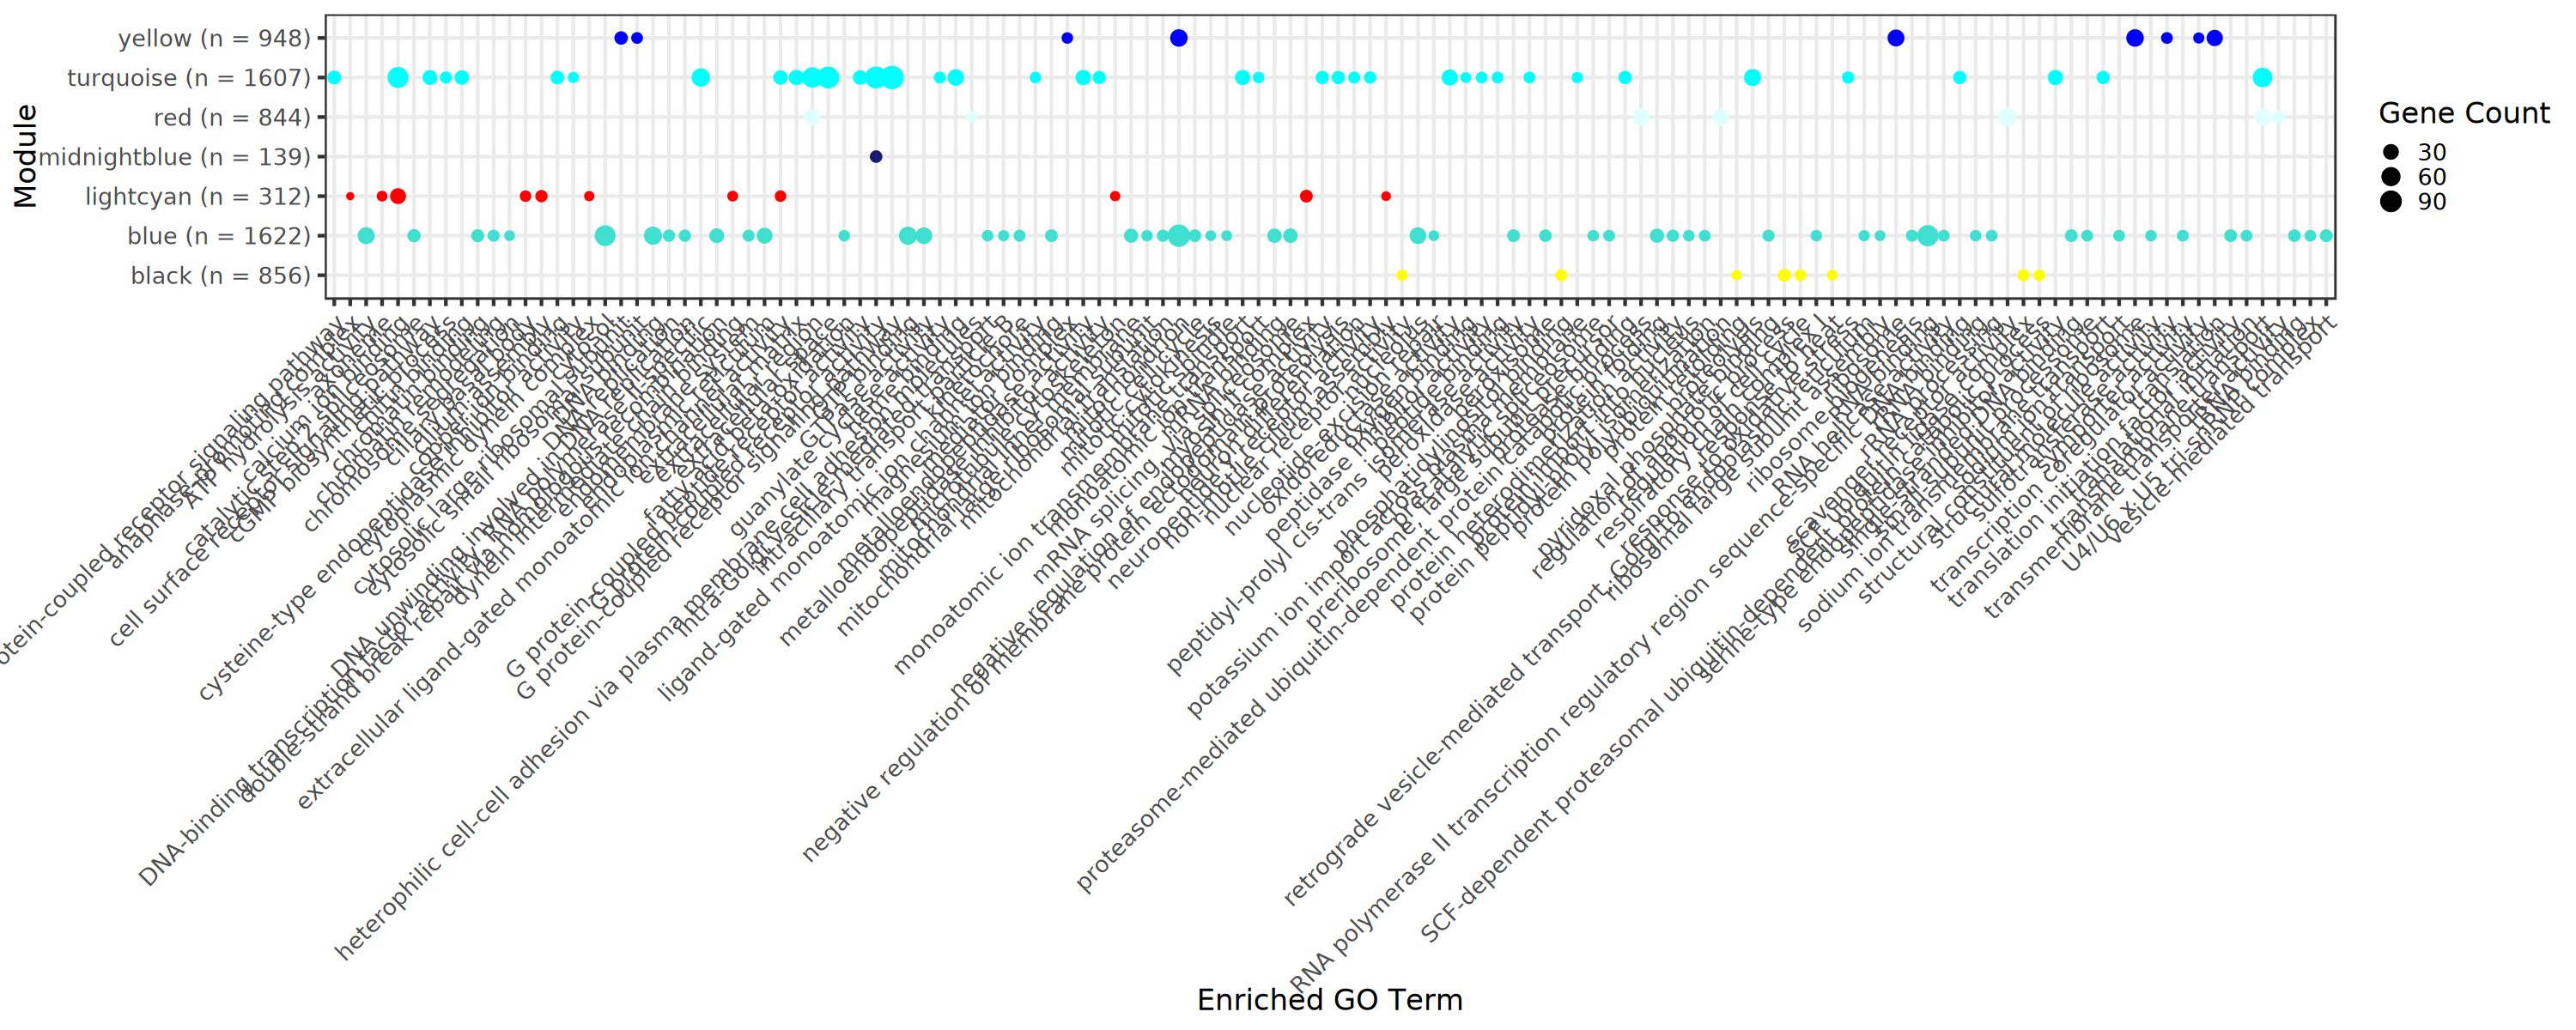

In [44]:
options(repr.plot.height = 10, repr.plot.width = 25)

module_gene_counts <- geneInfo %>%
  dplyr::count(ModuleColor)

module_labels <- setNames(
  paste0(module_gene_counts$ModuleColor, " (n = ", module_gene_counts$n, ")"),
  module_gene_counts$ModuleColor
)

ggplot(mod.all %>% filter(module %in% c('yellow', 'turquoise', 'red', 'midnightblue', 'lightcyan', 'cyan', 'blue', 'black')), aes(
  x = module,
  y = Description,
  size = Count,
  color = module
)) +
coord_flip() +
  guides(color = 'none') +
  scale_color_manual(values = c('yellow', 'turquoise', 'red', 'midnightblue', 'lightcyan', 'cyan', 'blue', 'black')) +
  scale_x_discrete(labels = module_labels) +
  geom_point() +
  labs(
    x = "Module",
    y = "Enriched GO Term",
    size = "Gene Count"
  ) +
  theme_bw(base_size = 20) +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

^ this is every enriched GO term, which is a lot to look at and potentially not that informative - instead, going to plot the GOSlim terms to get a broader idea of the enriched functions 

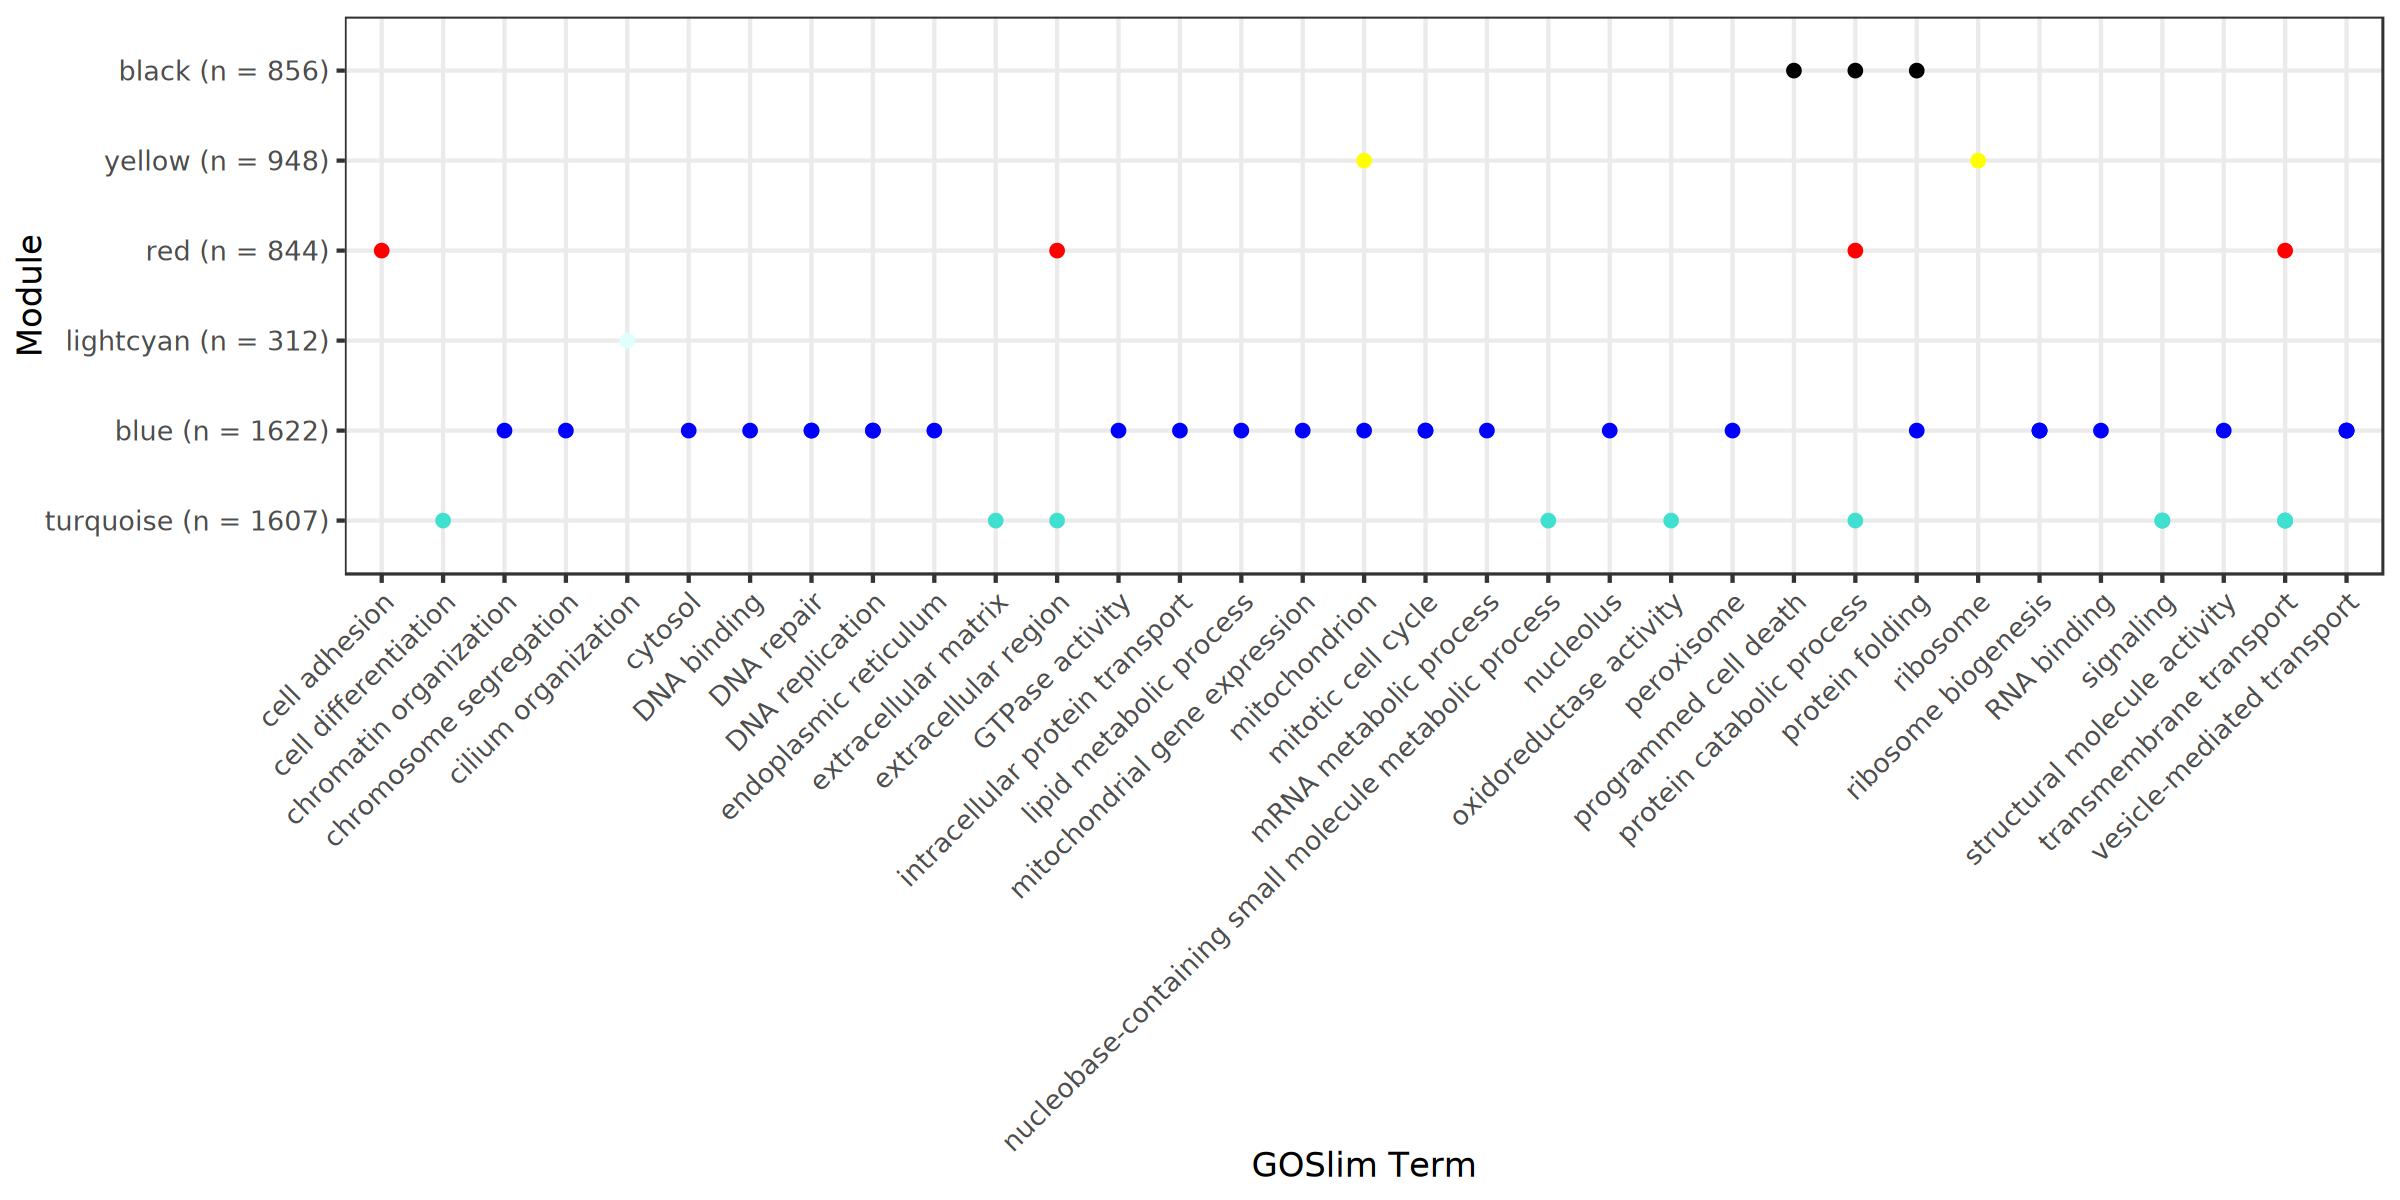

In [45]:
options(repr.plot.height = 10, repr.plot.width = 20)

module_order <- c(
  "turquoise",
  "blue",
  "cyan",
  "lightcyan",
  "red",
  "yellow",
  "black",
  "midnightblue"
)

mod.plot <- mod.slim %>%
  filter(module %in% module_order) %>%
  mutate(
    module = factor(module, levels = module_order)
  ) %>%
  arrange(module, desc(Count))


ggplot(mod.plot, aes(
  x = module,
  y = GOSlim_Bin,
  color = module
)) +
  geom_point() +
  coord_flip() +
  guides(color = "none") +
  scale_color_manual(values = c('yellow' = 'yellow', 'turquoise' = 'turquoise', 'red' = 'red', 'midnightblue' = 'midnightblue', 'lightcyan' = 'lightcyan', 'cyan' = 'cyan', 'blue' = 'blue', 'black' = 'black')) +
  scale_x_discrete(labels = module_labels) +
  labs(
    x = "Module",
    y = "GOSlim Term"
  ) +
  theme_bw(base_size = 20) + 
theme(axis.text.x = element_text(angle = 45, hjust = 1))

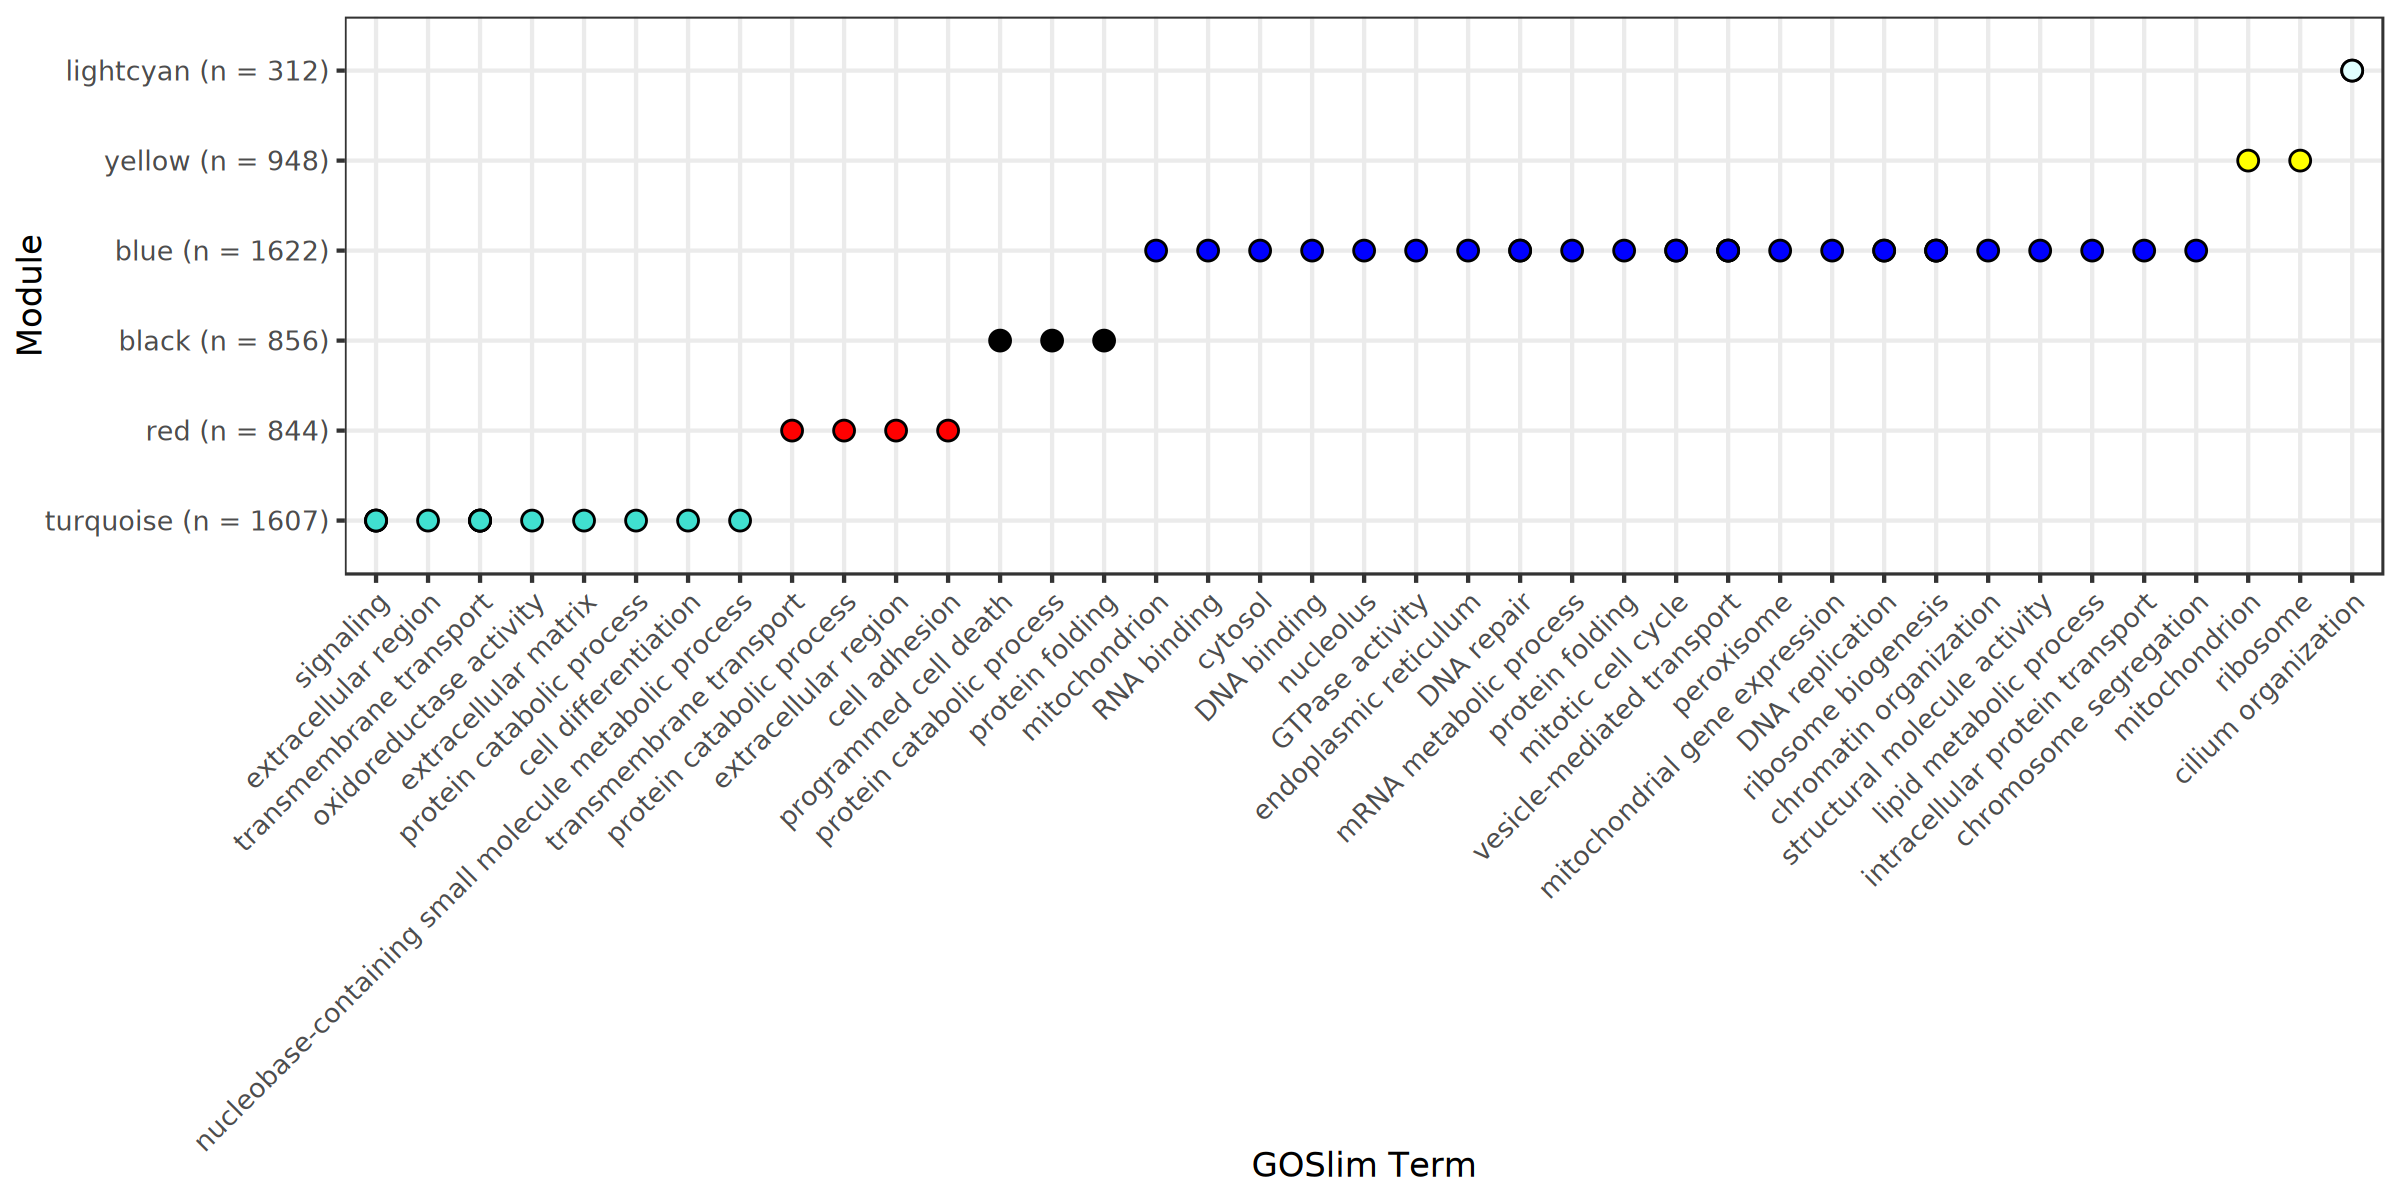

In [52]:
module_order <- c(
    'turquoise',
    'red',
    'black',
    'midnightblue',
    'blue',
    'yellow',
    'lightcyan'    
)

mod.plot <- mod.slim %>%
  filter(module %in% module_order) %>%
  mutate(
    module = factor(module, levels = module_order)
  ) %>%
  arrange(module, desc(Count)) %>%
  mutate(
    GO_order = paste(module, GOSlim_Bin, sep = "_")
  )

mod.plot$GO_order <- factor(
  mod.plot$GO_order,
  levels = unique(mod.plot$GO_order)
)

ggplot(mod.plot, aes(
  x = module,
  y = GO_order,
  fill = module
)) +
  geom_point(shape = 21, color = 'black', size = 5) +
  coord_flip() +
  guides(fill = "none") +
  scale_fill_manual(
    values = c(
      yellow = "yellow",
      turquoise = "turquoise",
      red = "red",
      midnightblue = "midnightblue",
      lightcyan = "lightcyan",
      cyan = "cyan",
      blue = "blue",
      black = "black"
    )
  ) +
  scale_x_discrete(labels = module_labels) +
  scale_y_discrete(
    labels = function(x) sub("^[^_]+_", "", x)
  ) +
  labs(
    x = "Module",
    y = "GOSlim Term"
  ) +
  theme_bw(base_size = 20) +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Phase 1 Modules

In [65]:
head(mod.all)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,module
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0003735,GO:0003735,structural constituent of ribosome,0.046413502,66/10514,1.091707e-30,3.853727e-28,3.849704e-28,LOC111100708/LOC111103150/LOC111103170/LOC111104145/LOC111104388/LOC111106383/LOC111111438/LOC111112701/LOC111114067/LOC111118104/LOC111118248/LOC111118348/LOC111118510/LOC111119040/LOC111119071/LOC111121601/LOC111126882/LOC111127437/LOC111128009/LOC111128024/LOC111128317/LOC111128580/LOC111128745/LOC111129410/LOC111130094/LOC111130218/LOC111132297/LOC111132903/LOC111133720/LOC111134500/LOC111135077/LOC111135100/LOC111135345/LOC111135849/LOC111136247/LOC111136411/LOC111136425/LOC144619705/LOC144620609/LOC144620712/LOC144621283/LOC144622911/LOC144624247/LOC144627618,44,yellow
GO:0005840,GO:0005840,ribosome,0.041139241,53/10514,5.975391e-30,1.054656e-27,1.053556e-27,LOC111100708/LOC111103170/LOC111104145/LOC111104388/LOC111106383/LOC111111438/LOC111112701/LOC111114067/LOC111118104/LOC111118248/LOC111118348/LOC111118510/LOC111119040/LOC111119071/LOC111121601/LOC111126882/LOC111127437/LOC111128009/LOC111128024/LOC111128317/LOC111128580/LOC111128745/LOC111129410/LOC111130094/LOC111130218/LOC111132297/LOC111132903/LOC111133720/LOC111135077/LOC111135849/LOC111136247/LOC111136411/LOC111136425/LOC144619705/LOC144620609/LOC144620712/LOC144621283/LOC144622911/LOC144627618,39,yellow
GO:0006412,GO:0006412,translation,0.035864979,52/10514,1.487619e-23,1.750432e-21,1.748605e-21,LOC111100708/LOC111103170/LOC111104145/LOC111104388/LOC111106383/LOC111111438/LOC111114067/LOC111118104/LOC111118248/LOC111118348/LOC111118510/LOC111119040/LOC111119071/LOC111121601/LOC111126882/LOC111127437/LOC111128009/LOC111128024/LOC111128317/LOC111128580/LOC111129410/LOC111130094/LOC111130218/LOC111132903/LOC111133720/LOC111135077/LOC111135849/LOC111136411/LOC111136425/LOC144620609/LOC144620712/LOC144621283/LOC144622911/LOC144624247,34,yellow
GO:0022625,GO:0022625,cytosolic large ribosomal subunit,0.016877637,17/10514,2.647790e-16,2.336675e-14,2.334236e-14,LOC111103150/LOC111103170/LOC111118104/LOC111119071/LOC111121601/LOC111127437/LOC111128745/LOC111132297/LOC111133720/LOC111134500/LOC111135345/LOC111135849/LOC111136247/LOC144620609/LOC144622911/LOC144627618,16,yellow
GO:0022627,GO:0022627,cytosolic small ribosomal subunit,0.009493671,11/10514,1.769519e-08,1.249280e-06,1.247976e-06,LOC111100708/LOC111104388/LOC111114067/LOC111119040/LOC111126882/LOC111128317/LOC111128580/LOC144619705/LOC144620712,9,yellow
GO:0005739,GO:0005739,mitochondrion,0.046413502,239/10514,3.301799e-06,1.942559e-04,1.940531e-04,LOC111103072/LOC111103250/LOC111104128/LOC111104702/LOC111105388/LOC111105598/LOC111105879/LOC111107699/LOC111110359/LOC111112266/LOC111113204/LOC111114527/LOC111116418/LOC111116974/LOC111117976/LOC111118461/LOC111118593/LOC111118872/LOC111120712/LOC111121504/LOC111121719/LOC111127001/LOC111128123/LOC111128157/LOC111128302/LOC111128323/LOC111128659/LOC111128742/LOC111128795/LOC111129409/LOC111130026/LOC111130282/LOC111130608/LOC111130738/LOC111133170/LOC111133413/LOC111134951/LOC111135130/LOC111135526/LOC111136411/LOC144620328/LOC144620891/LOC144623752/LOC144625632,44,yellow


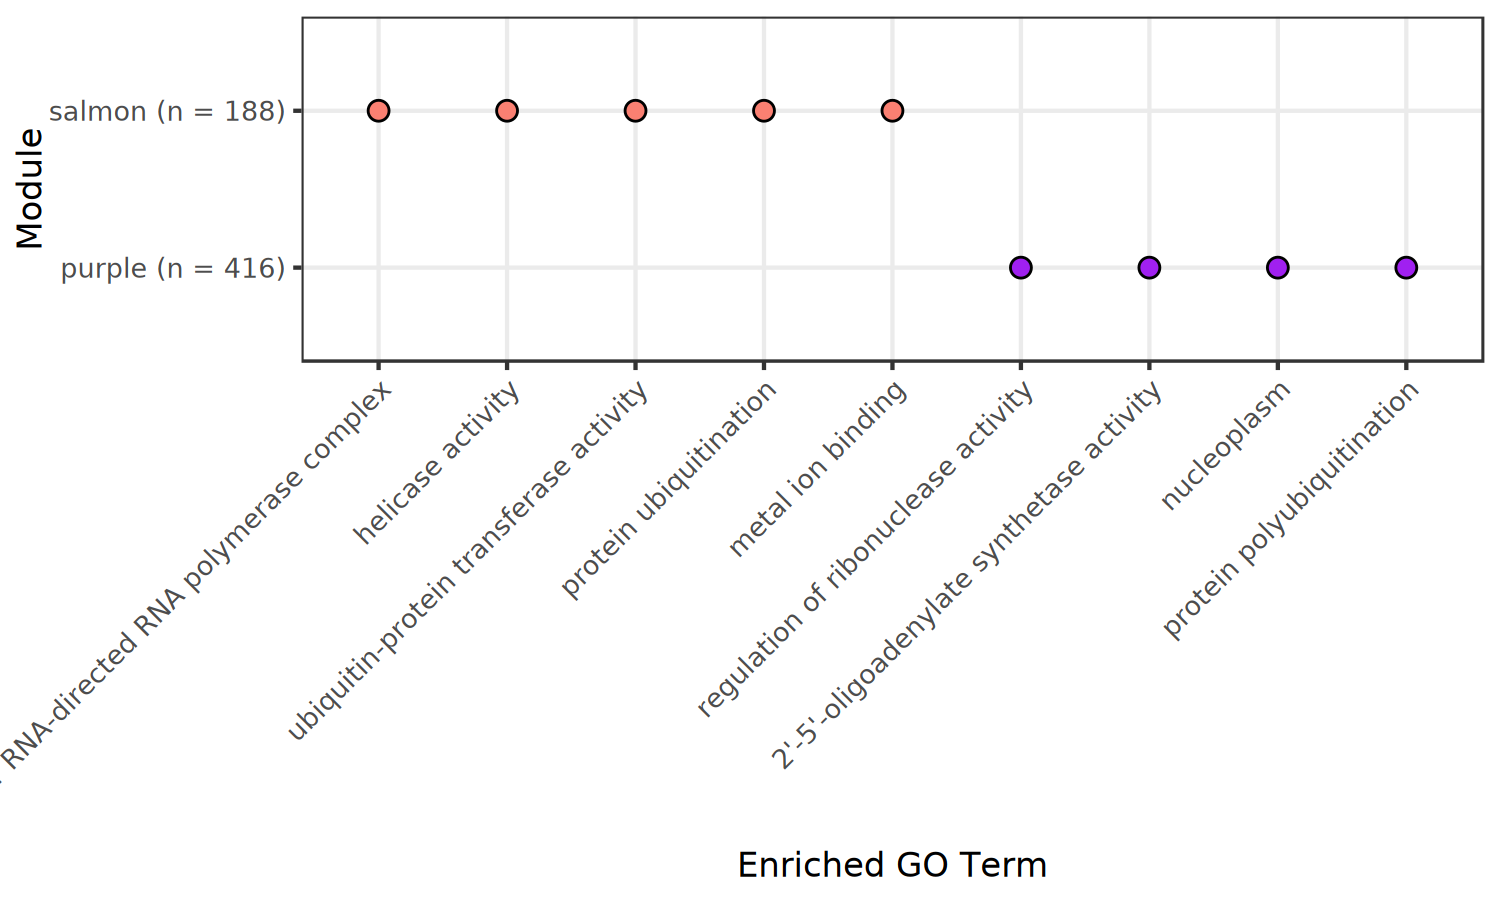

In [55]:
options(repr.plot.height = 7.5, repr.plot.width = 12.5)

# Keep only the modules of interest and order GO terms within each module
mod.plot <- mod.all %>%
  filter(module %in% c("salmon", "purple")) %>%
  arrange(module, desc(Count)) %>%
  mutate(
    Description = factor(
      Description,
      levels = rev(unique(Description))
    )
  )

ggplot(mod.plot, aes(
  x = module,
  y = Description,
  fill = module
)) +
  geom_point(size = 5, shape = 21, color = 'black') +
  coord_flip() +
  guides(fill = "none") +
  scale_fill_manual(values = c("purple" = "purple", "salmon" = "salmon")) +
  scale_x_discrete(labels = module_labels) +
  labs(
    x = "Module",
    y = "Enriched GO Term"
  ) +
  theme_bw(base_size = 20) + 
theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Phase 2 Treatment Modules

^ this is every enriched GO term, which is a lot to look at and potentially not that informative - instead, going to plot the GOSlim terms to get a broader idea of the enriched functions 

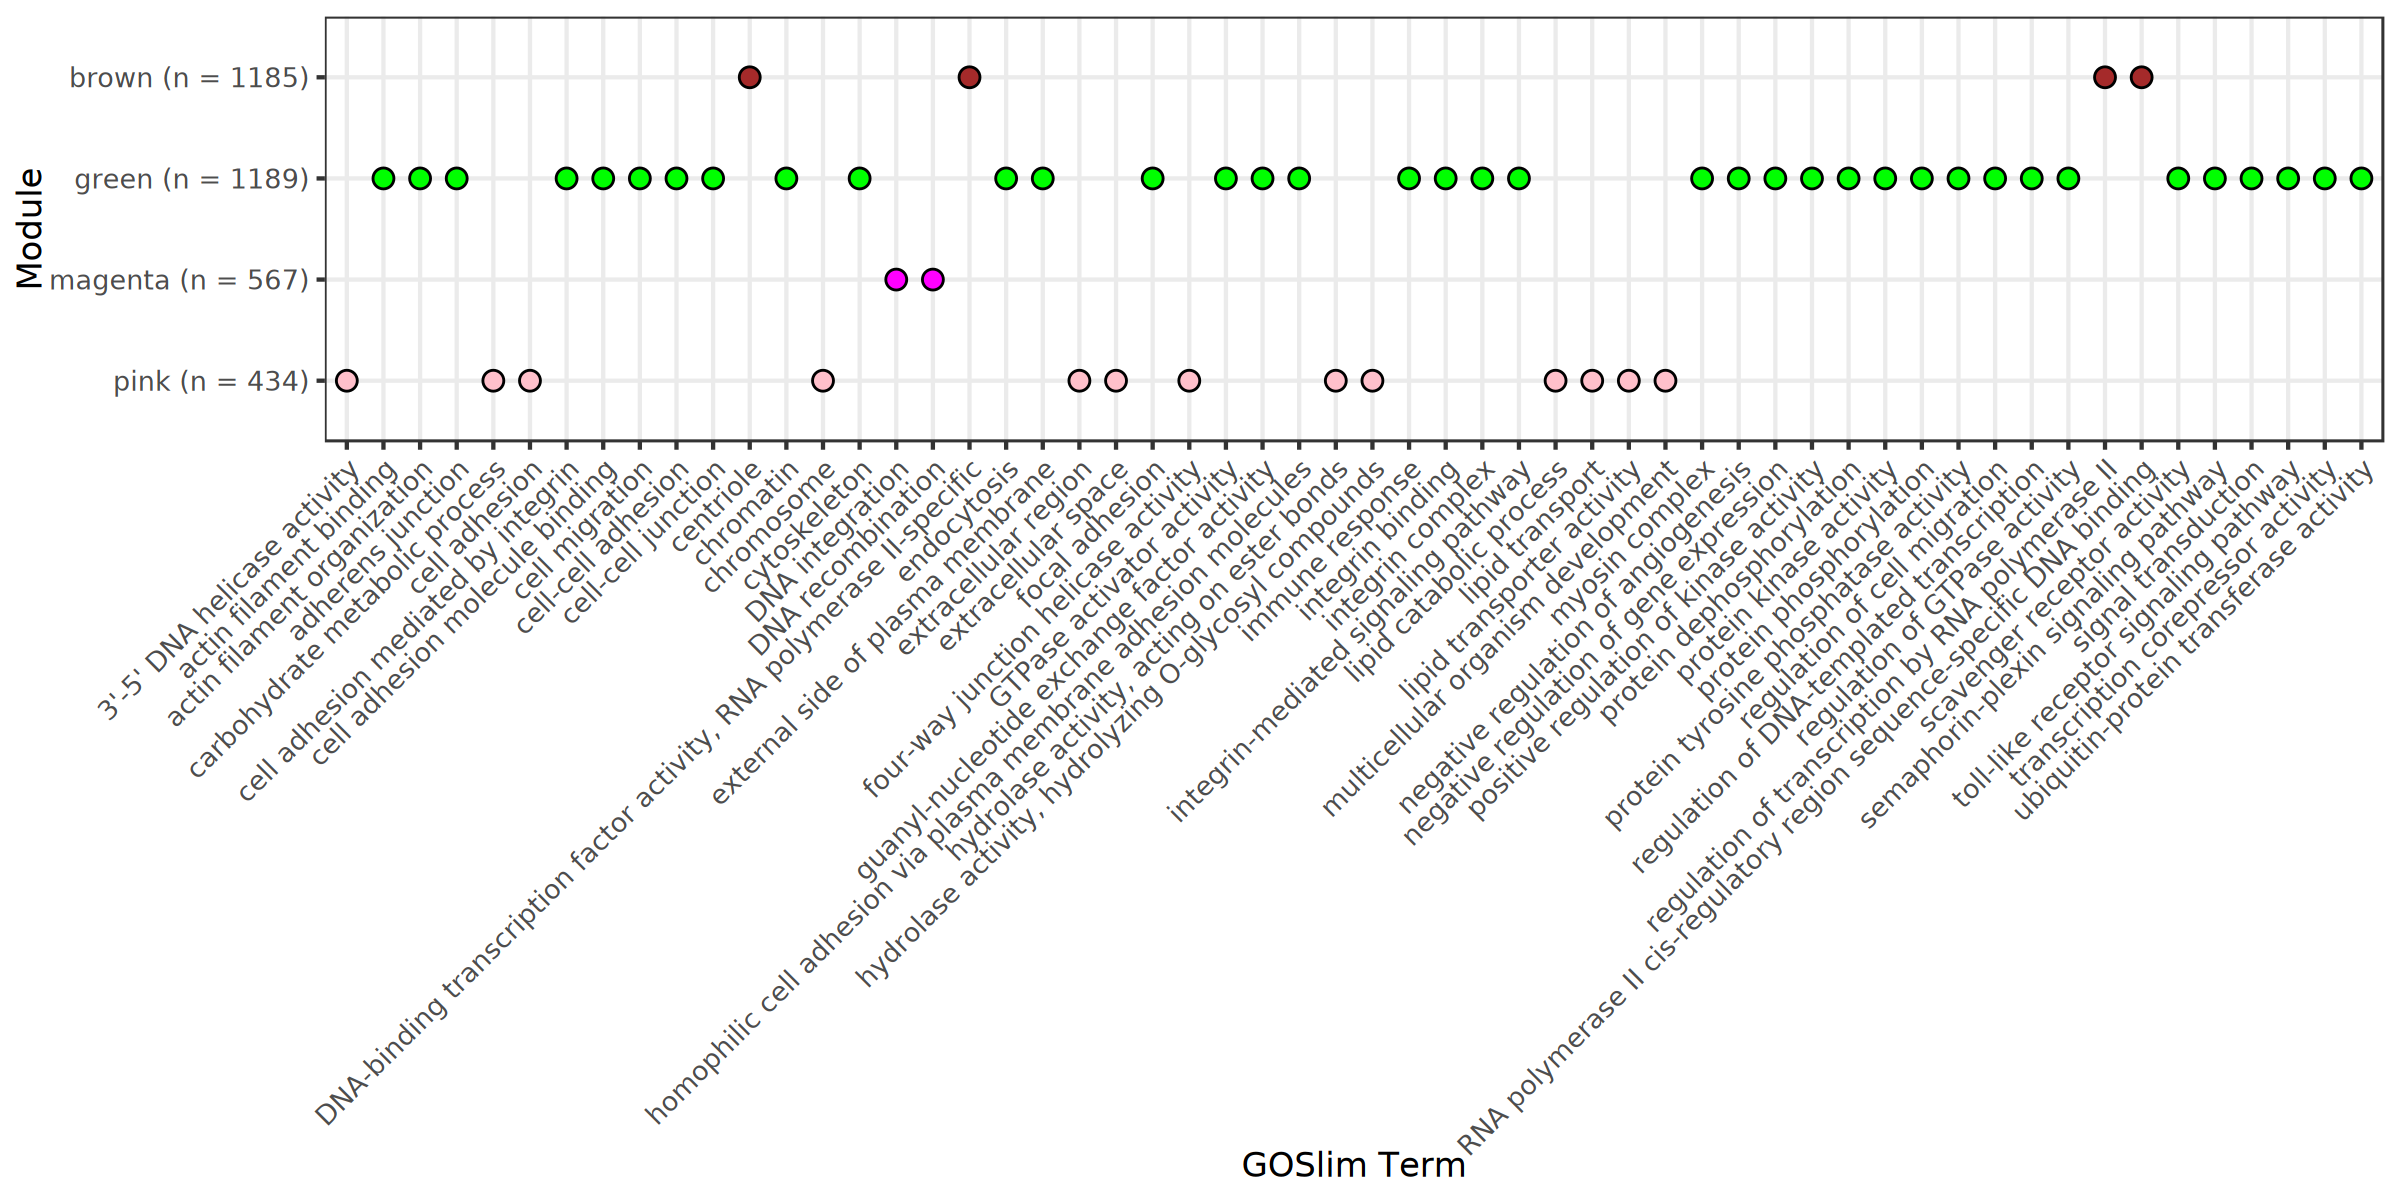

In [66]:
options(repr.plot.height = 10, repr.plot.width = 20)

module_order <- c(
    'pink',
    'magenta',
    'green',
    'brown'
)

mod.plot <- mod.all %>%
  filter(module %in% module_order) %>%
  mutate(
    module = factor(module, levels = module_order)
  ) %>%
  arrange(module, desc(Count))


ggplot(mod.plot, aes(
  x = module,
  y = Description,
  fill = module
)) +
  geom_point(shape = 21, size = 5, color = 'black') +
  coord_flip() +
  guides(fill = "none") +
  scale_fill_manual(values = c('pink' = 'pink', 'magenta' = 'magenta', 'green' = 'green', 'brown' = 'brown')) +
  scale_x_discrete(labels = module_labels) +
  labs(
    x = "Module",
    y = "GOSlim Term"
  ) +
  theme_bw(base_size = 20) + 
theme(axis.text.x = element_text(angle = 45, hjust = 1))

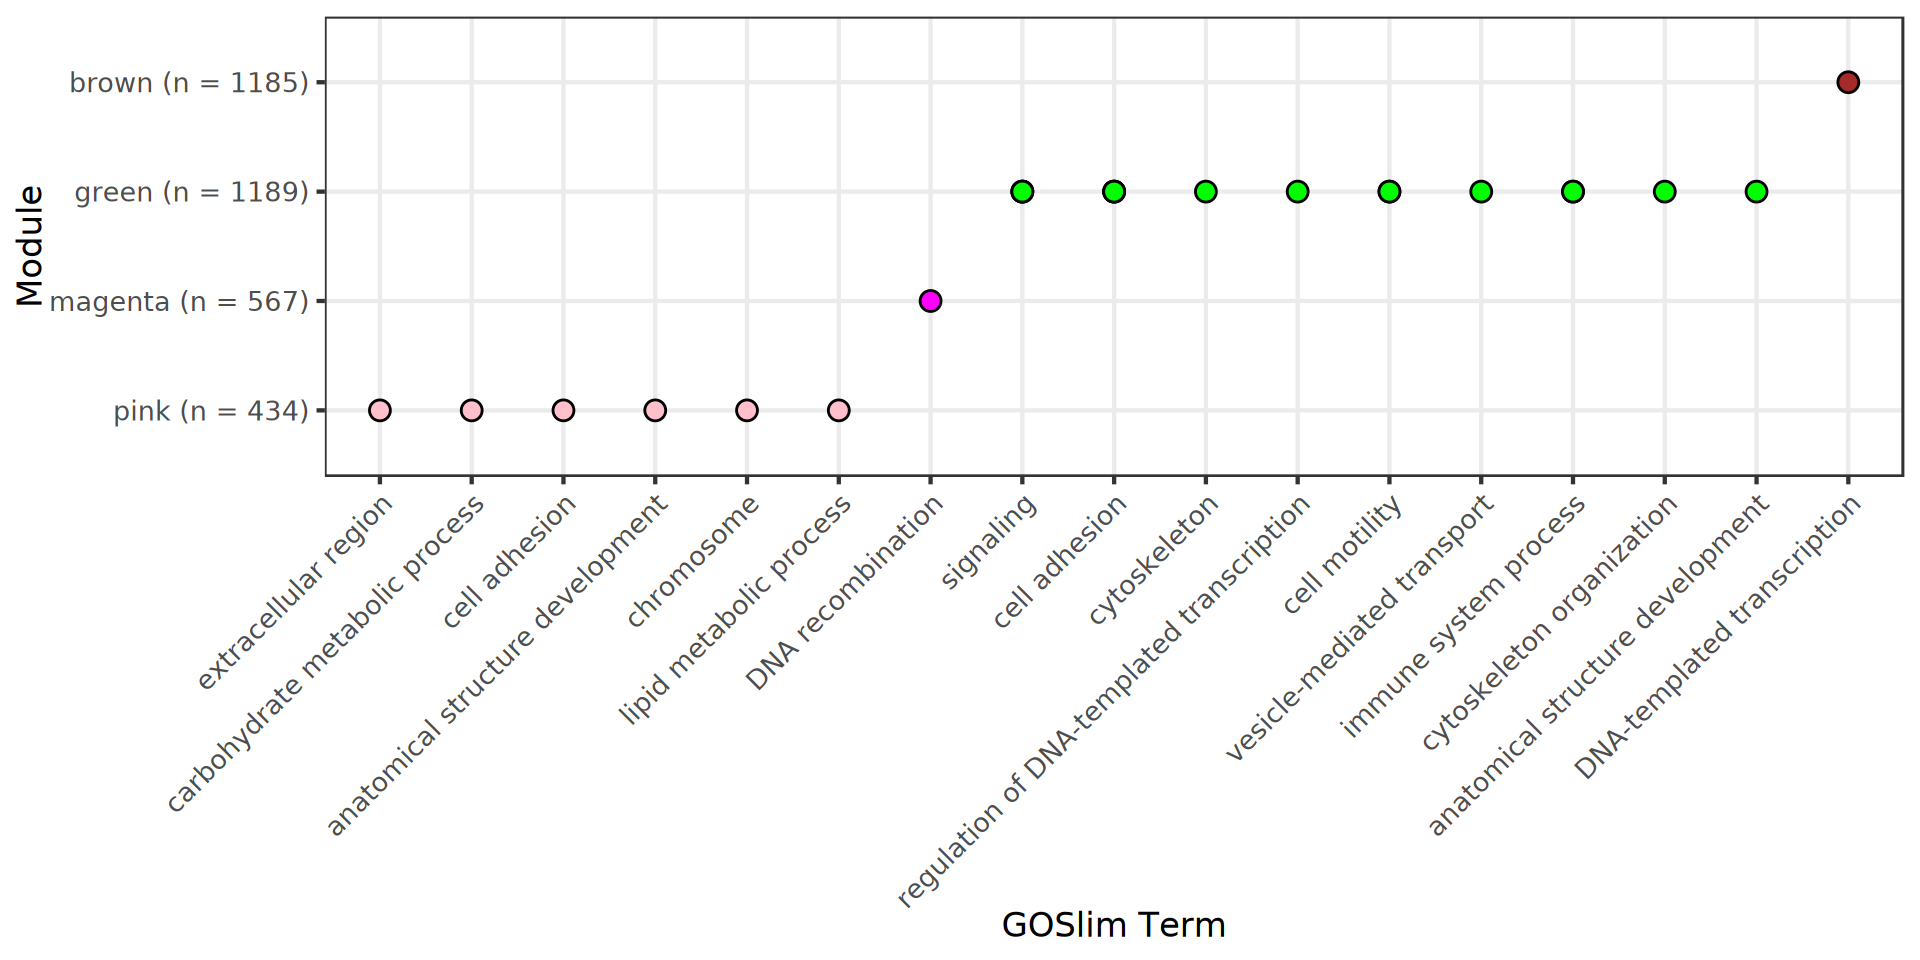

In [61]:
options(repr.plot.height = 8, repr.plot.width = 16)

module_order <- c(
    'pink',
    'magenta',
    'green',
    'brown'
)

mod.plot <- mod.slim %>%
  filter(module %in% module_order) %>%
  mutate(
    module = factor(module, levels = module_order)
  ) %>%
  arrange(module, desc(Count)) %>%
  mutate(
    GO_order = paste(module, GOSlim_Bin, sep = "_")
  )

mod.plot$GO_order <- factor(
  mod.plot$GO_order,
  levels = unique(mod.plot$GO_order)
)

ggplot(mod.plot, aes(
  x = module,
  y = GO_order,
  fill = module
)) +
  geom_point(shape = 21, color = 'black', size = 5) +
  coord_flip() +
  guides(fill = "none") +
  scale_fill_manual(values = c('pink' = 'pink', 'magenta' = 'magenta', 'green' = 'green', 'brown' = 'brown')) +
  scale_x_discrete(labels = module_labels) +
  scale_y_discrete(
    labels = function(x) sub("^[^_]+_", "", x)
  ) +
  labs(
    x = "Module",
    y = "GOSlim Term"
  ) +
  theme_bw(base_size = 20) +
theme(axis.text.x = element_text(angle = 45, hjust = 1))